# MiniGrid VLM Benchmark — History Results Analysis

Analyse of results from `results_hist/results/raw/`. Each run adds a 5-step history context.
Three **modes** are compared: `baseline` (no special prompt), `cot` (chain-of-thought), `thinking` (extended thinking).
Two **history types** are compared: `optimal` (past actions were good) vs `suboptimal` (past actions were noisy).

In [3]:
RAW_DIR = "./results_hist/results/raw"  # folder containing all JSON files

MODEL_ORDER   = ["qwen3b", "qwen7b", "internvl", "internvl3", "qwen2vl", "internvl8b_mpo", "wethink"]
VARIANT_ORDER = ["if_then", "negative_rules", "verbose", "optimal"]
ACTION_ORDER  = ["turn_left", "turn_right", "forward", "pickup", "toggle"]
MODE_ORDER    = ["baseline", "cot", "thinking"]
HIST_ORDER    = ["optimal", "suboptimal"]
HIST_IMAGES_ORDER = [0, 3, 5]   # values of --history_images used in the run

In [4]:
import json
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({"figure.dpi": 130, "font.size": 11})
sns.set_style("whitegrid")

## 0. Load all JSON files into a single DataFrame

In [5]:
raw_dir = Path(RAW_DIR)
records = []
for fpath in sorted(raw_dir.glob("*.json")):
    with open(fpath) as f:
        records.extend(json.load(f))

df = pd.DataFrame(records)

def _to_list(v):
    return v if isinstance(v, list) else ast.literal_eval(v)

df["opt_list"] = df["optimal_actions"].apply(_to_list)

ACTION_MAP = {0: "turn_left", 1: "turn_right", 2: "forward", 3: "pickup", 5: "toggle"}
df["predicted_label"] = df["predicted_action"].map(ACTION_MAP)

print(f"Total samples : {len(df):,}")
print(f"Models        : {sorted(df['model'].unique())}")
print(f"Modes         : {sorted(df['mode'].unique())}")
print(f"History types : {sorted(df['history_type'].unique())}")
print(f"Variants      : {sorted(df['variant'].unique())}")
print(f"Envs          : {sorted(df['env'].unique())}")
df.head(3)

Total samples : 21,600
Models        : ['internvl8b_mpo', 'qwen2vl', 'qwen7b', 'wethink']
Modes         : ['baseline', 'cot', 'thinking']
History types : ['optimal', 'suboptimal']
Variants      : ['negative_rules', 'optimal']
Envs          : ['MiniGrid-DoorKey-16x16-v0', 'MiniGrid-DoorKey-5x5-v0', 'MiniGrid-DoorKey-8x8-v0', 'MiniGrid-Empty-16x16-v0', 'MiniGrid-Empty-8x8-v0']


,sample_id,model,model_name,view,variant,history_images,mode,env,complexity,mission,...,phase,optimal_actions,action_names,raw_output,predicted_action,correct,parse_failed,latency_ms,opt_list,predicted_label
0,00000,internvl8b_mpo,InternVL2.5 8B MPO,global,negative_rules,0,baseline,MiniGrid-Empty-8x8-v0,simple,get to the green goal square,...,navigate,"[0, 1]","[turn_left, turn_right]",1,1.0,True,False,1468,"[0, 1]",turn_right
1,00001,internvl8b_mpo,InternVL2.5 8B MPO,global,negative_rules,0,baseline,MiniGrid-Empty-8x8-v0,simple,get to the green goal square,...,navigate,[2],[forward],2,2.0,True,False,186,[2],forward
2,00002,internvl8b_mpo,InternVL2.5 8B MPO,global,negative_rules,0,baseline,MiniGrid-Empty-8x8-v0,simple,get to the green goal square,...,navigate,[0],[turn_left],2,2.0,False,False,184,[0],forward


## 1. Overall accuracy — model × mode × history_type

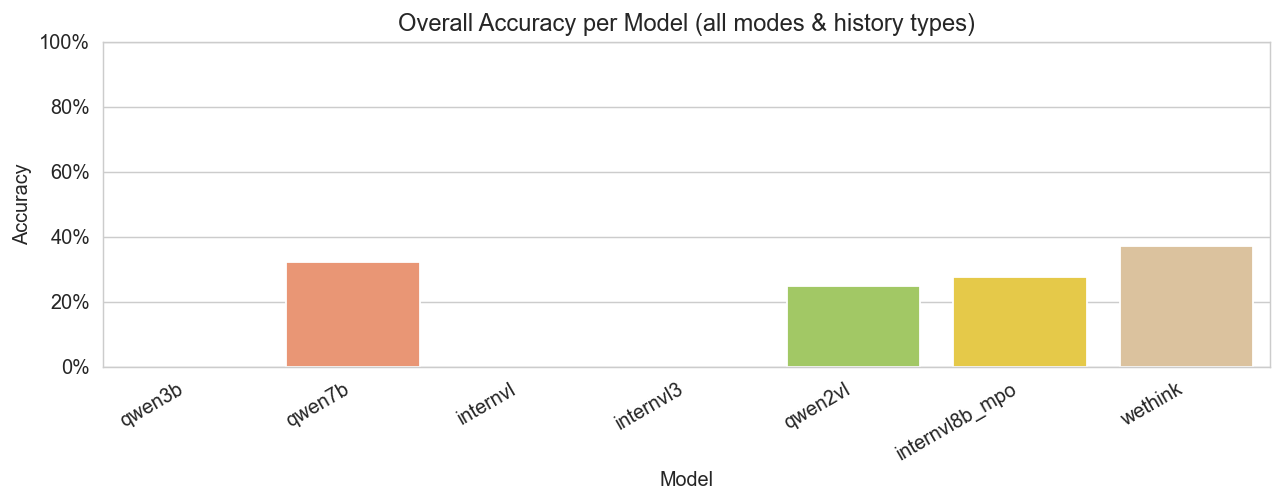

In [6]:
# Accuracy per model (aggregated over all modes and history types)
acc_model = df.groupby("model")["correct"].mean().reindex(MODEL_ORDER)

plt.figure(figsize=(10, 4))
sns.barplot(x=acc_model.index, y=acc_model.values, palette="Set2")
plt.ylim(0, 1)
plt.title("Overall Accuracy per Model (all modes & history types)")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=30, ha="right")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

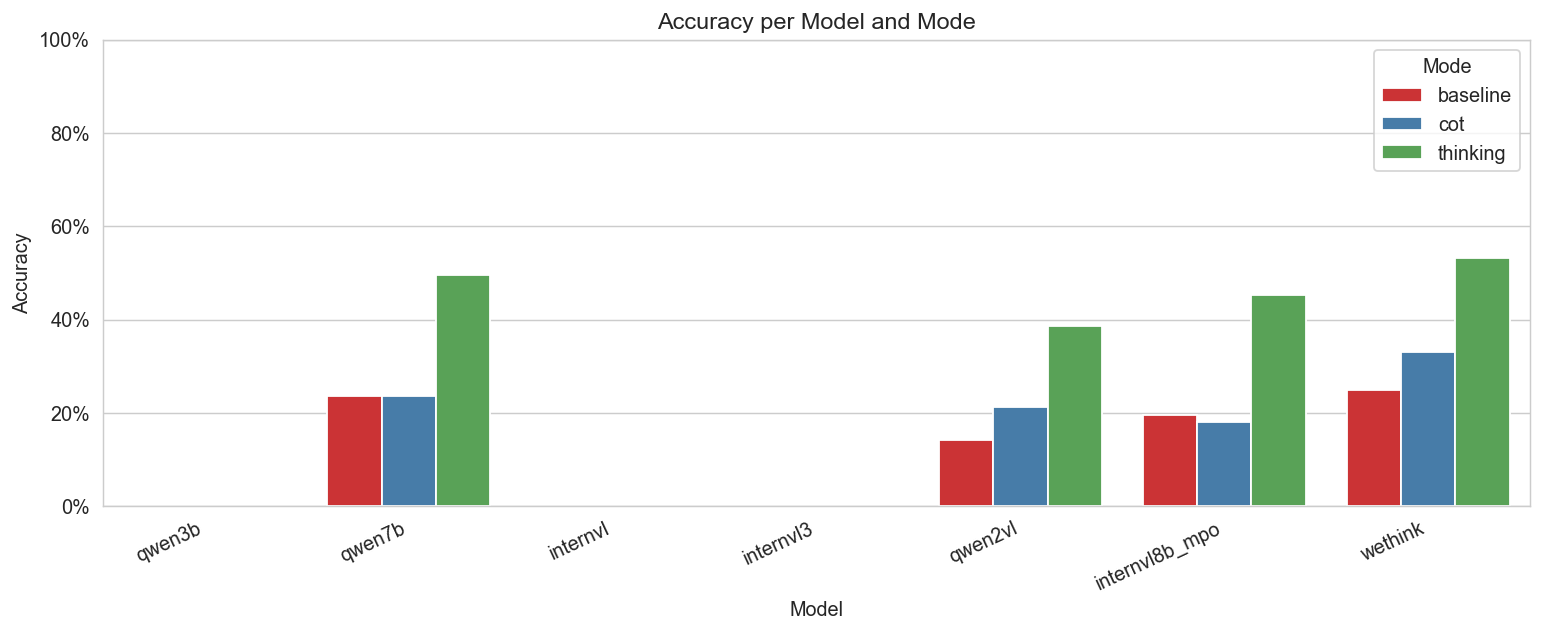

In [7]:
# Accuracy per model × mode
acc_mm = df.groupby(["model", "mode"])["correct"].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=acc_mm, x="model", y="correct",
    hue="mode", hue_order=MODE_ORDER,
    order=MODEL_ORDER, palette="Set1", ax=ax
)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Accuracy per Model and Mode", fontsize=13)
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy")
ax.legend(title="Mode")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

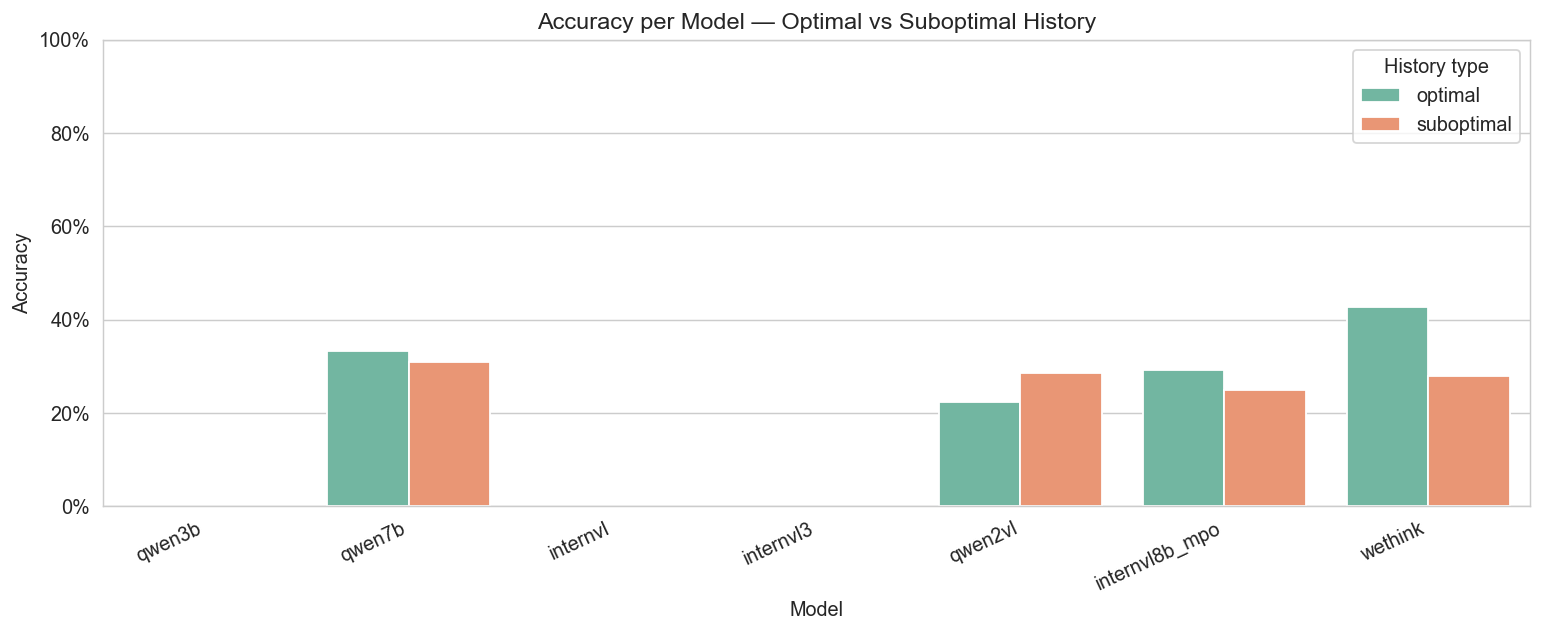

In [8]:
# Accuracy per model × history_type (optimal vs suboptimal)
acc_mh = df.groupby(["model", "history_type"])["correct"].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=acc_mh, x="model", y="correct",
    hue="history_type", hue_order=HIST_ORDER,
    order=MODEL_ORDER, palette="Set2", ax=ax
)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Accuracy per Model — Optimal vs Suboptimal History", fontsize=13)
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy")
ax.legend(title="History type")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 1b. F1 Score analysis (macro & per-action)

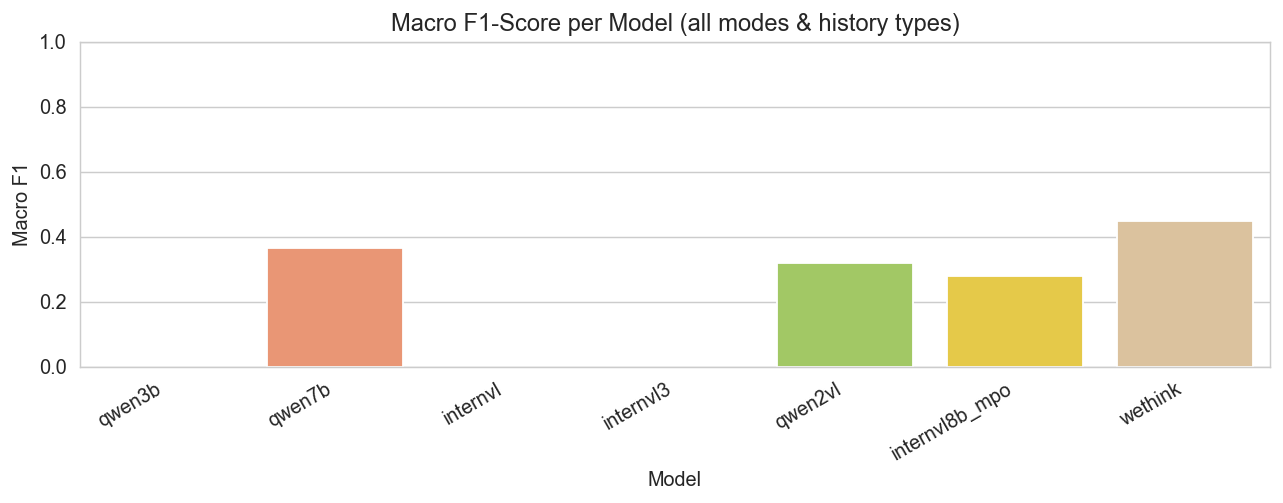

In [9]:
from sklearn.metrics import f1_score

ACTION_LABELS_F1  = ["turn_left", "turn_right", "forward", "pickup", "toggle"]
ACTION_INDICES_F1 = [0, 1, 2, 3, 5]

# Work on single-optimal rows for an unambiguous ground truth
df_f1 = df[df["opt_list"].apply(len) == 1].copy()
df_f1["optimal_action"] = df_f1["opt_list"].apply(lambda x: x[0])

def macro_f1(sub):
    if len(sub) == 0:
        return np.nan
    y_true = sub["optimal_action"].values
    y_pred = sub["predicted_action"].values
    mask = np.isin(y_pred, ACTION_INDICES_F1)
    if mask.sum() == 0:
        return np.nan
    return f1_score(y_true[mask], y_pred[mask],
                    labels=ACTION_INDICES_F1, average="macro", zero_division=0)

def per_class_f1(sub):
    """Returns a Series indexed by action label."""
    if len(sub) == 0:
        return pd.Series(np.nan, index=ACTION_LABELS_F1)
    y_true = sub["optimal_action"].values
    y_pred = sub["predicted_action"].values
    mask = np.isin(y_pred, ACTION_INDICES_F1)
    scores = f1_score(y_true[mask], y_pred[mask],
                      labels=ACTION_INDICES_F1, average=None, zero_division=0)
    return pd.Series(scores, index=ACTION_LABELS_F1)

# ── 1. Global macro-F1 per model ──────────────────────────────────────────────
f1_model = df_f1.groupby("model").apply(macro_f1).reindex(MODEL_ORDER)

plt.figure(figsize=(10, 4))
sns.barplot(x=f1_model.index, y=f1_model.values, palette="Set2")
plt.ylim(0, 1)
plt.title("Macro F1-Score per Model (all modes & history types)")
plt.ylabel("Macro F1")
plt.xlabel("Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

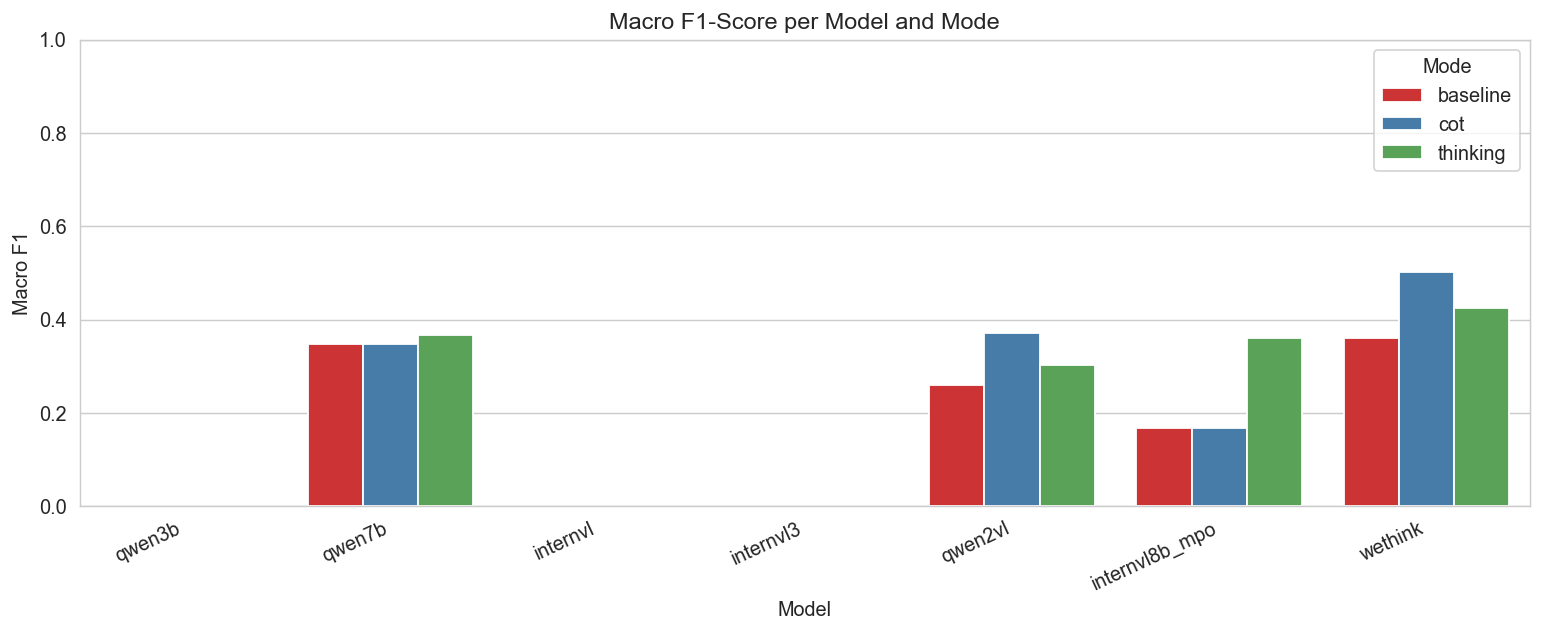

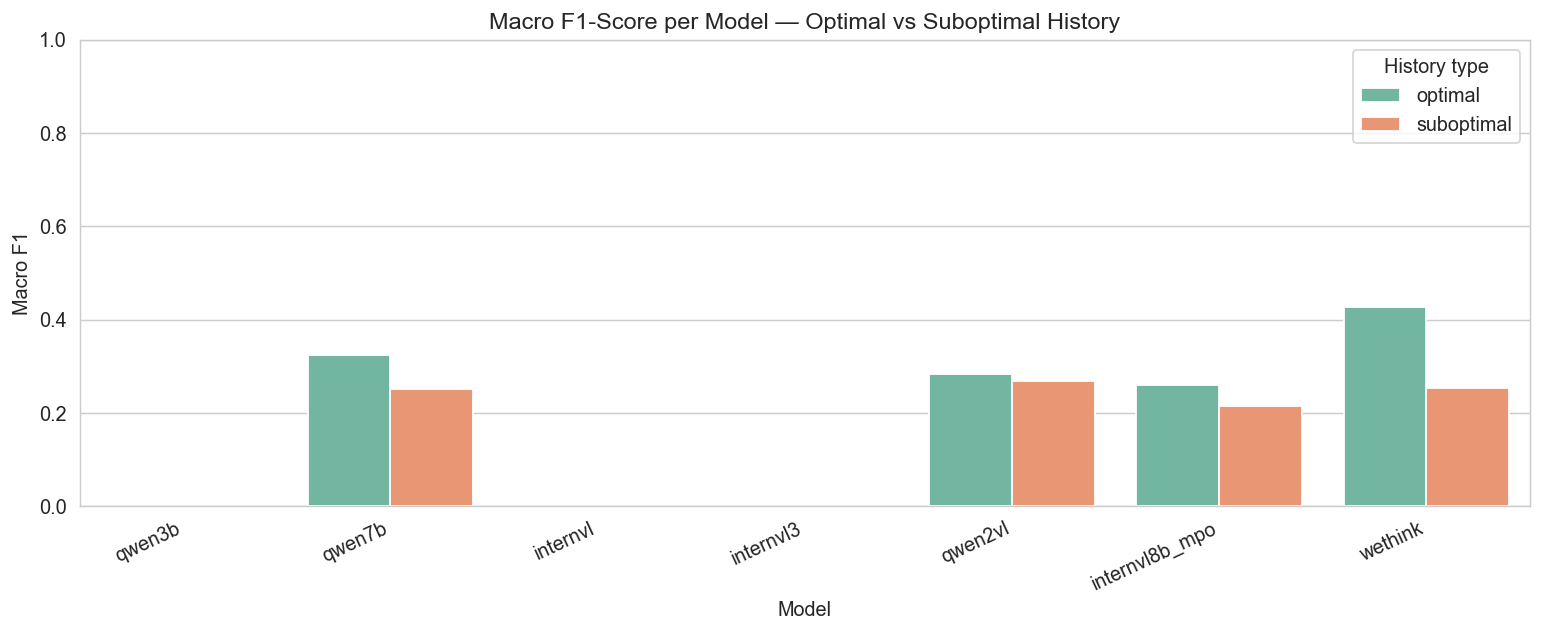

In [10]:
# ── 2. Macro-F1 per model × mode (grouped bar) ────────────────────────────────
f1_mm = df_f1.groupby(["model", "mode"]).apply(macro_f1).reset_index()
f1_mm.columns = ["model", "mode", "f1"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=f1_mm, x="model", y="f1",
    hue="mode", hue_order=MODE_ORDER,
    order=MODEL_ORDER, palette="Set1", ax=ax
)
ax.set_ylim(0, 1)
ax.set_title("Macro F1-Score per Model and Mode", fontsize=13)
ax.set_xlabel("Model")
ax.set_ylabel("Macro F1")
ax.legend(title="Mode")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# ── 3. Macro-F1 per model × history_type (grouped bar) ────────────────────────
f1_mh = df_f1.groupby(["model", "history_type"]).apply(macro_f1).reset_index()
f1_mh.columns = ["model", "history_type", "f1"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=f1_mh, x="model", y="f1",
    hue="history_type", hue_order=HIST_ORDER,
    order=MODEL_ORDER, palette="Set2", ax=ax
)
ax.set_ylim(0, 1)
ax.set_title("Macro F1-Score per Model — Optimal vs Suboptimal History", fontsize=13)
ax.set_xlabel("Model")
ax.set_ylabel("Macro F1")
ax.legend(title="History type")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

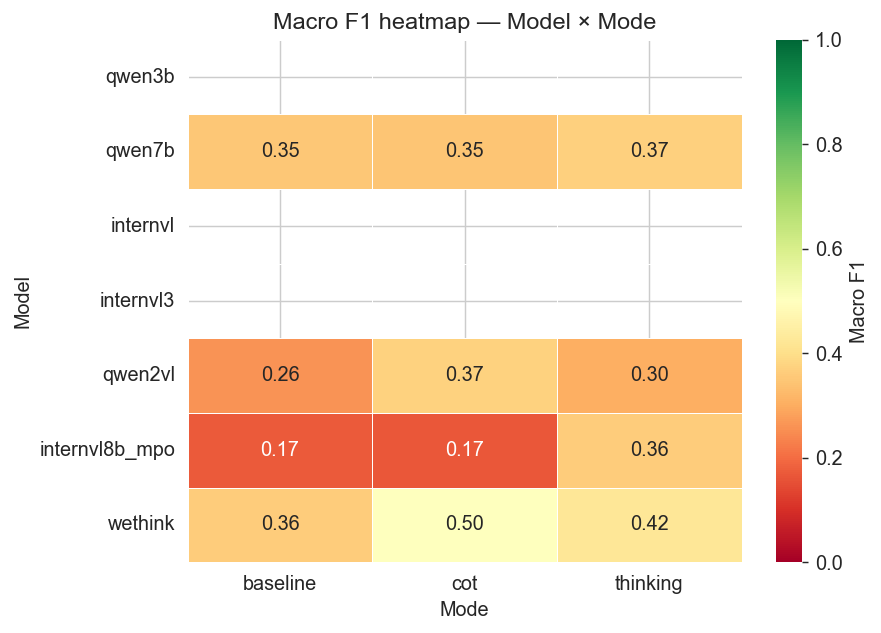

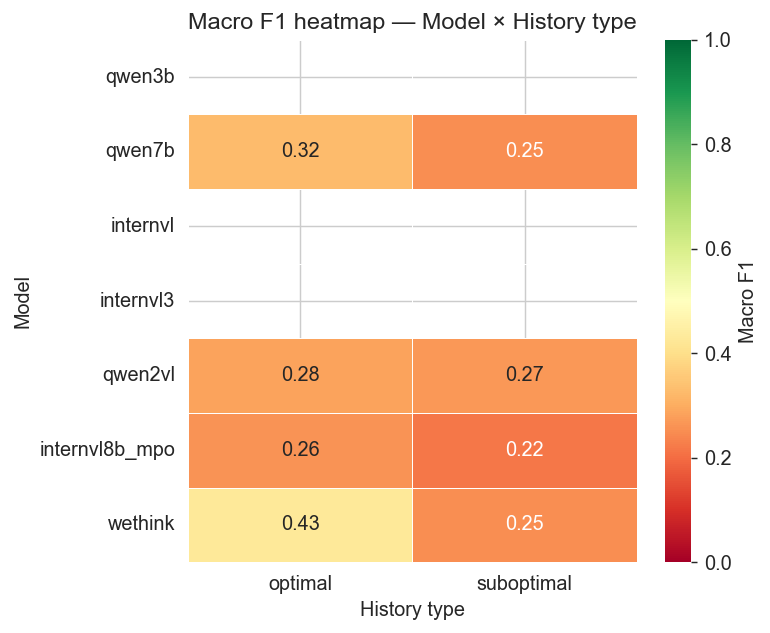

In [11]:
# ── 4. Heatmap model × mode (macro-F1) ────────────────────────────────────────
pivot_f1_mode = f1_mm.pivot(index="model", columns="mode", values="f1")
pivot_f1_mode = pivot_f1_mode.reindex(MODEL_ORDER)[MODE_ORDER]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    pivot_f1_mode, annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
    cbar_kws={"label": "Macro F1"}
)
ax.set_title("Macro F1 heatmap — Model × Mode", fontsize=13)
ax.set_xlabel("Mode")
ax.set_ylabel("Model")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# ── 5. Heatmap model × history_type (macro-F1) ────────────────────────────────
pivot_f1_hist = f1_mh.pivot(index="model", columns="history_type", values="f1")
pivot_f1_hist = pivot_f1_hist.reindex(MODEL_ORDER)[HIST_ORDER]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    pivot_f1_hist, annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
    cbar_kws={"label": "Macro F1"}
)
ax.set_title("Macro F1 heatmap — Model × History type", fontsize=13)
ax.set_xlabel("History type")
ax.set_ylabel("Model")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

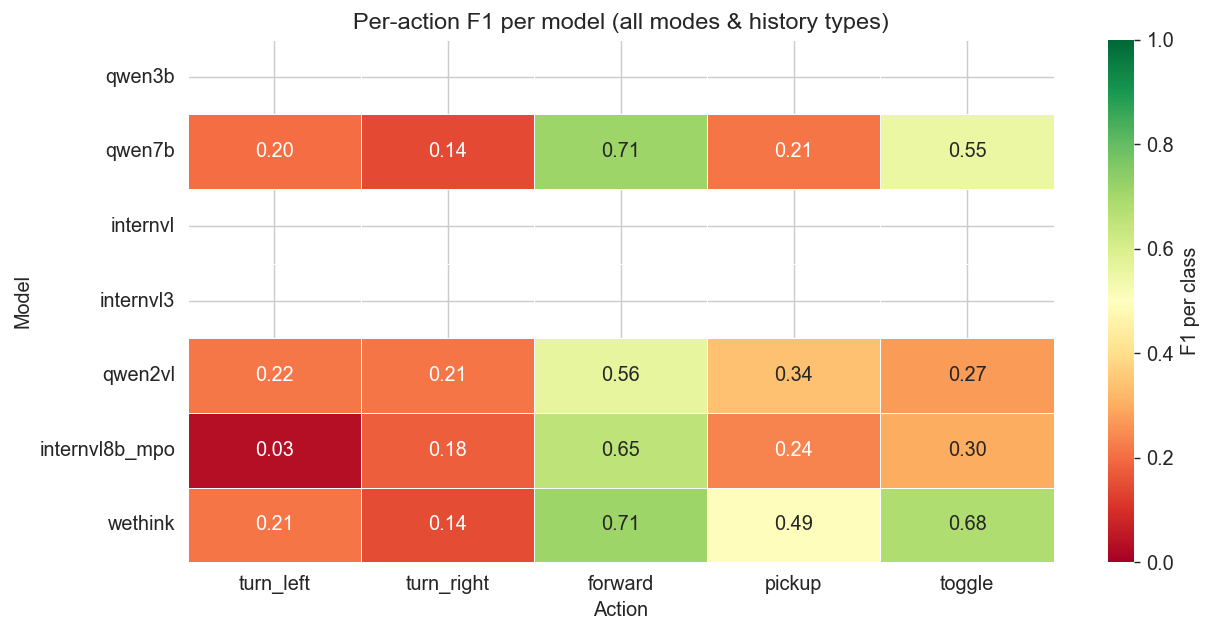

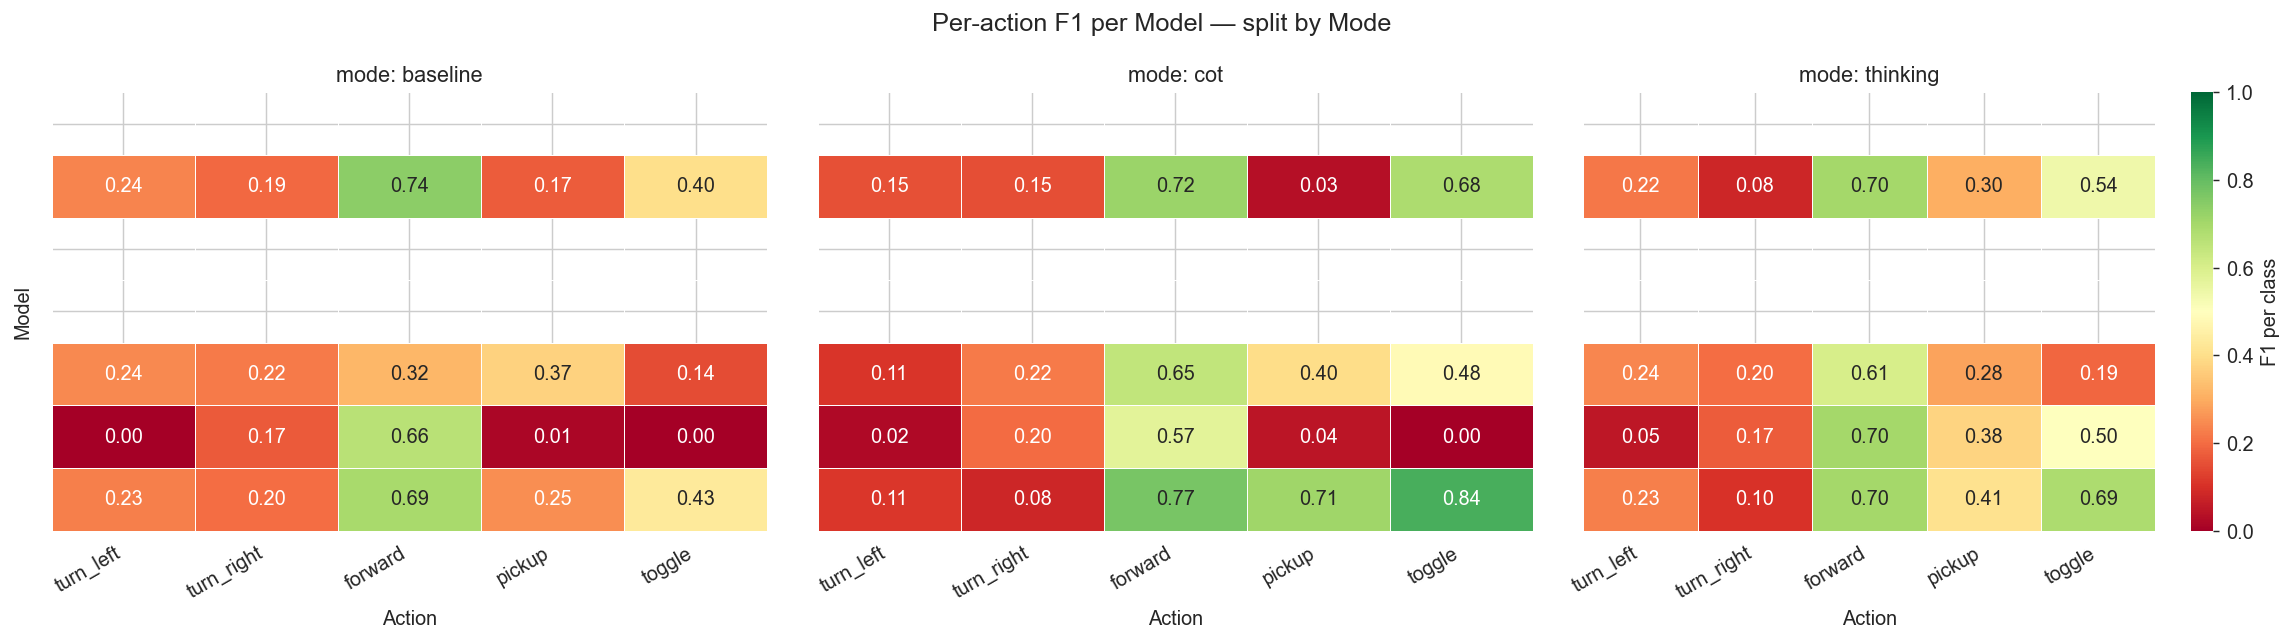

In [12]:
# ── 6. Per-class F1 heatmap — model × action ──────────────────────────────────
rows = []
for model in MODEL_ORDER:
    sub = df_f1[df_f1["model"] == model]
    s = per_class_f1(sub)
    s.name = model
    rows.append(s)

pivot_f1_action = pd.DataFrame(rows)[ACTION_LABELS_F1]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot_f1_action, annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
    cbar_kws={"label": "F1 per class"}
)
ax.set_title("Per-action F1 per model (all modes & history types)", fontsize=13)
ax.set_xlabel("Action")
ax.set_ylabel("Model")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# ── 7. Per-class F1 per mode — one heatmap per mode ───────────────────────────
fig, axes = plt.subplots(1, len(MODE_ORDER), figsize=(18, 5), sharey=True)
fig.suptitle("Per-action F1 per Model — split by Mode", fontsize=14)

for ax, mode in zip(axes, MODE_ORDER):
    rows = []
    for model in MODEL_ORDER:
        sub = df_f1[(df_f1["model"] == model) & (df_f1["mode"] == mode)]
        s = per_class_f1(sub)
        s.name = model
        rows.append(s)
    pivot = pd.DataFrame(rows)[ACTION_LABELS_F1]
    sns.heatmap(
        pivot, annot=True, fmt=".2f", cmap="RdYlGn",
        vmin=0, vmax=1, linewidths=0.5, ax=ax,
        cbar=(mode == MODE_ORDER[-1]),
        cbar_kws={"label": "F1 per class"}
    )
    ax.set_title(f"mode: {mode}", fontsize=12)
    ax.set_xlabel("Action")
    if mode == MODE_ORDER[0]:
        ax.set_ylabel("Model")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()

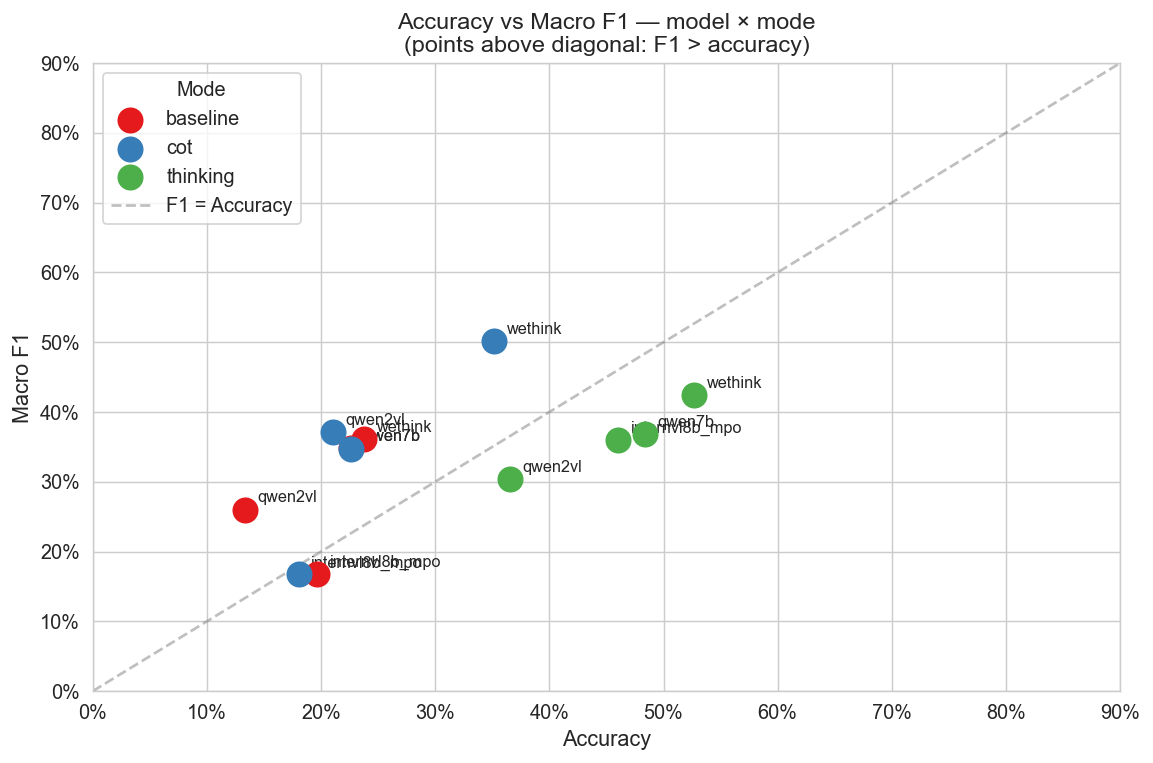

In [13]:
# ── 8. Accuracy vs Macro-F1 scatter — one point per (model, mode) ─────────────
acc_f1 = df_f1.groupby(["model", "mode"]).agg(
    accuracy=("correct", "mean")
).reset_index()
acc_f1 = acc_f1.merge(f1_mm, on=["model", "mode"])

palette = sns.color_palette("Set1", len(MODE_ORDER))
mode_color = {m: c for m, c in zip(MODE_ORDER, palette)}

fig, ax = plt.subplots(figsize=(9, 6))
for mode in MODE_ORDER:
    sub = acc_f1[acc_f1["mode"] == mode]
    ax.scatter(sub["accuracy"], sub["f1"], s=180, color=mode_color[mode], label=mode, zorder=5)
    for _, row in sub.iterrows():
        ax.annotate(row["model"], (row["accuracy"], row["f1"]),
                    textcoords="offset points", xytext=(7, 4), fontsize=9)

ax.plot([0, 1], [0, 1], color="gray", linestyle="--", alpha=0.5, label="F1 = Accuracy")
ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Accuracy", fontsize=12)
ax.set_ylabel("Macro F1", fontsize=12)
ax.set_title("Accuracy vs Macro F1 — model × mode\n(points above diagonal: F1 > accuracy)", fontsize=13)
ax.legend(title="Mode")
plt.tight_layout()
plt.show()

## 2. Effect of mode (baseline / cot / thinking)

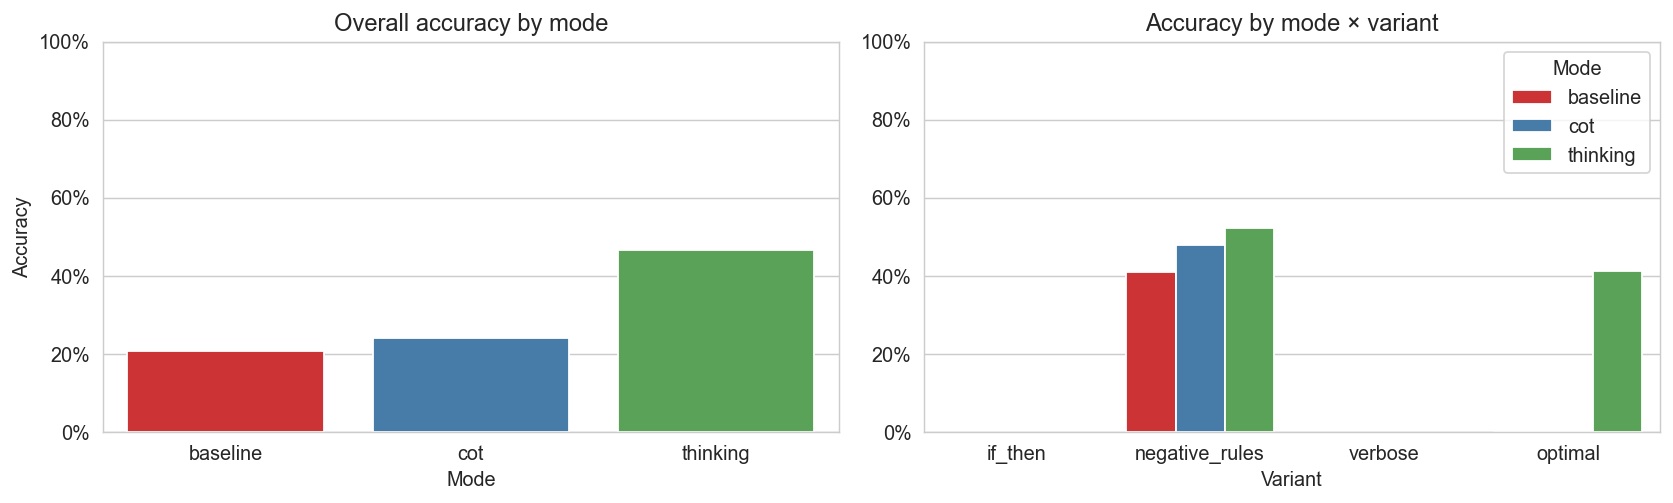

In [14]:
# Global accuracy per mode
acc_mode = df.groupby("mode")["correct"].mean().reindex(MODE_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(x=acc_mode.index, y=acc_mode.values, palette="Set1", ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title("Overall accuracy by mode")
axes[0].set_xlabel("Mode")
axes[0].set_ylabel("Accuracy")

# Accuracy per mode × variant
acc_mv = df.groupby(["mode", "variant"])["correct"].mean().reset_index()
sns.barplot(
    data=acc_mv, x="variant", y="correct",
    hue="mode", hue_order=MODE_ORDER,
    order=VARIANT_ORDER, palette="Set1", ax=axes[1]
)
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Accuracy by mode × variant")
axes[1].set_xlabel("Variant")
axes[1].set_ylabel("")
axes[1].legend(title="Mode")

plt.tight_layout()
plt.show()

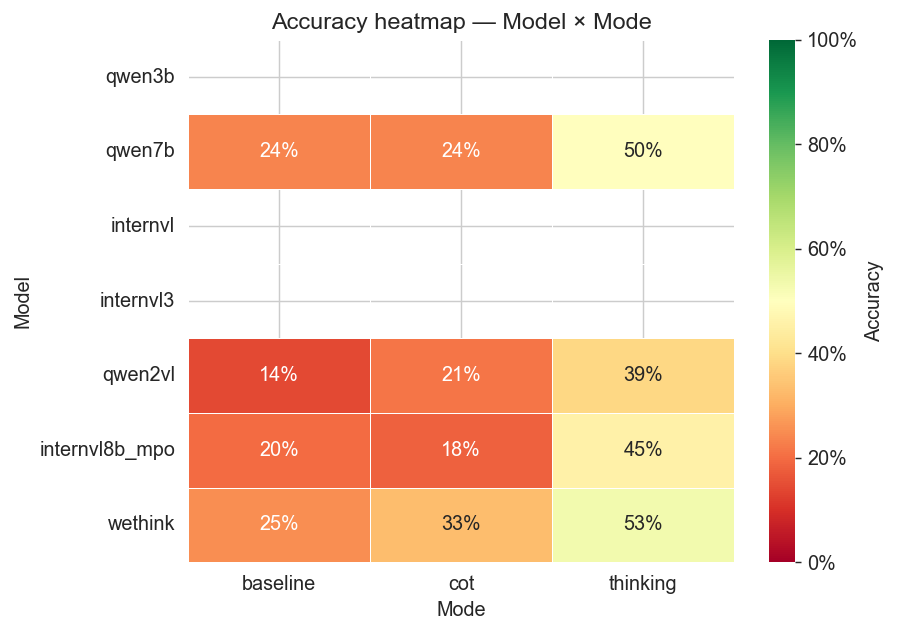

In [15]:
# Heatmap: model × mode accuracy
pivot_mode = df.groupby(["model", "mode"])["correct"].mean().unstack().reindex(MODEL_ORDER)
pivot_mode = pivot_mode.reindex(columns=MODE_ORDER)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    pivot_mode, annot=True, fmt=".0%", cmap="RdYlGn",
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
    cbar_kws={"label": "Accuracy", "format": mtick.PercentFormatter(1.0)}
)
ax.set_title("Accuracy heatmap — Model × Mode", fontsize=13)
ax.set_xlabel("Mode")
ax.set_ylabel("Model")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 3. Effect of history quality (optimal vs suboptimal)

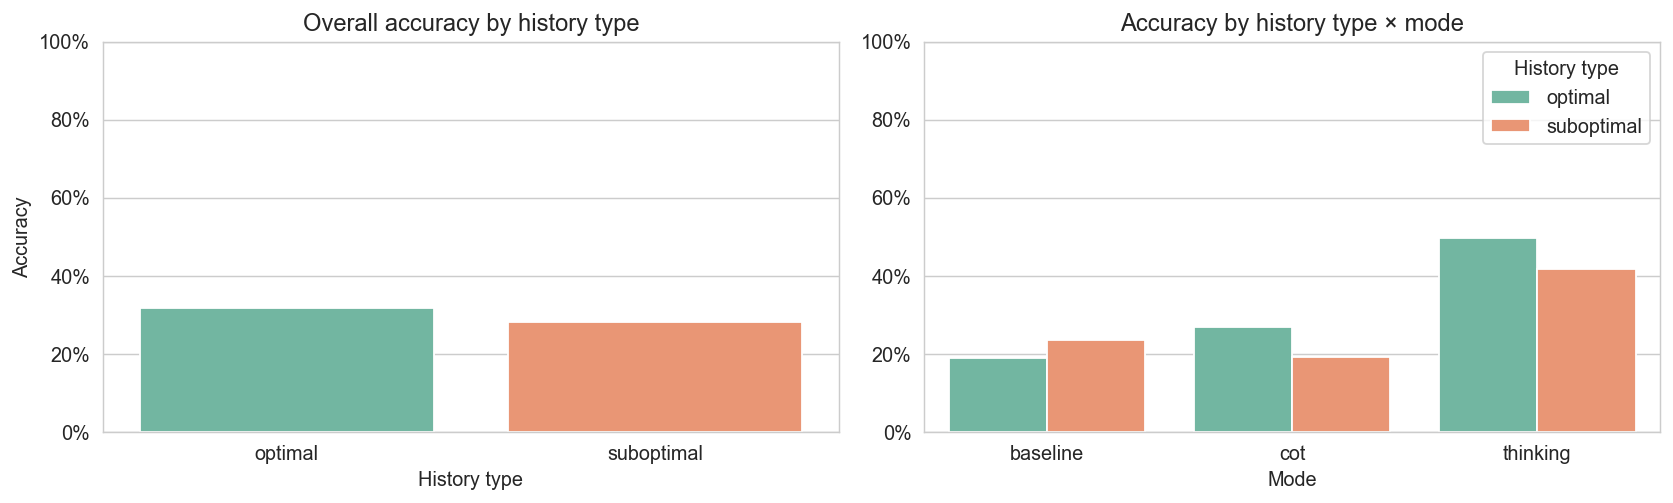

In [16]:
# Global accuracy per history_type
acc_ht = df.groupby("history_type")["correct"].mean().reindex(HIST_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(x=acc_ht.index, y=acc_ht.values, palette="Set2", ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title("Overall accuracy by history type")
axes[0].set_xlabel("History type")
axes[0].set_ylabel("Accuracy")

# Accuracy per history_type × mode
acc_htm = df.groupby(["history_type", "mode"])["correct"].mean().reset_index()
sns.barplot(
    data=acc_htm, x="mode", y="correct",
    hue="history_type", hue_order=HIST_ORDER,
    order=MODE_ORDER, palette="Set2", ax=axes[1]
)
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Accuracy by history type × mode")
axes[1].set_xlabel("Mode")
axes[1].set_ylabel("")
axes[1].legend(title="History type")

plt.tight_layout()
plt.show()

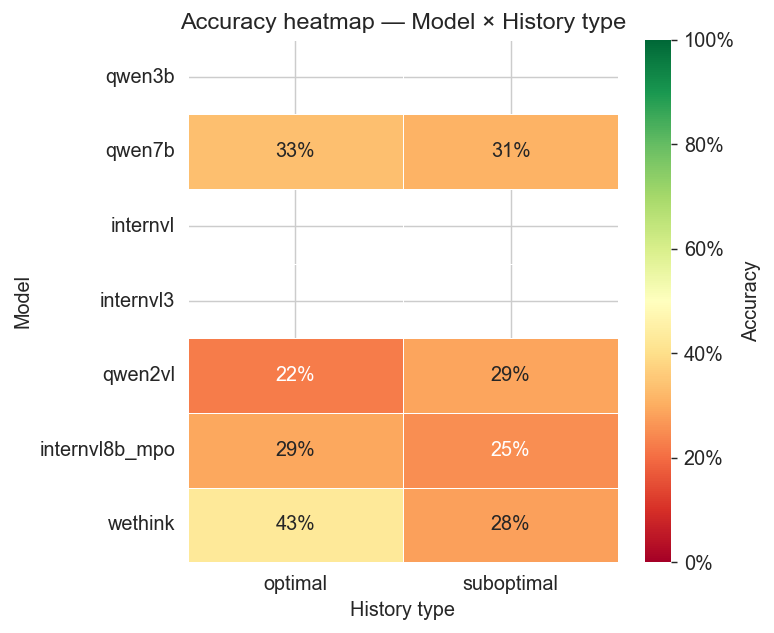

In [17]:
# Heatmap: model × history_type
pivot_hist = df.groupby(["model", "history_type"])["correct"].mean().unstack().reindex(MODEL_ORDER)
pivot_hist = pivot_hist.reindex(columns=HIST_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    pivot_hist, annot=True, fmt=".0%", cmap="RdYlGn",
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
    cbar_kws={"label": "Accuracy", "format": mtick.PercentFormatter(1.0)}
)
ax.set_title("Accuracy heatmap — Model × History type", fontsize=13)
ax.set_xlabel("History type")
ax.set_ylabel("Model")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

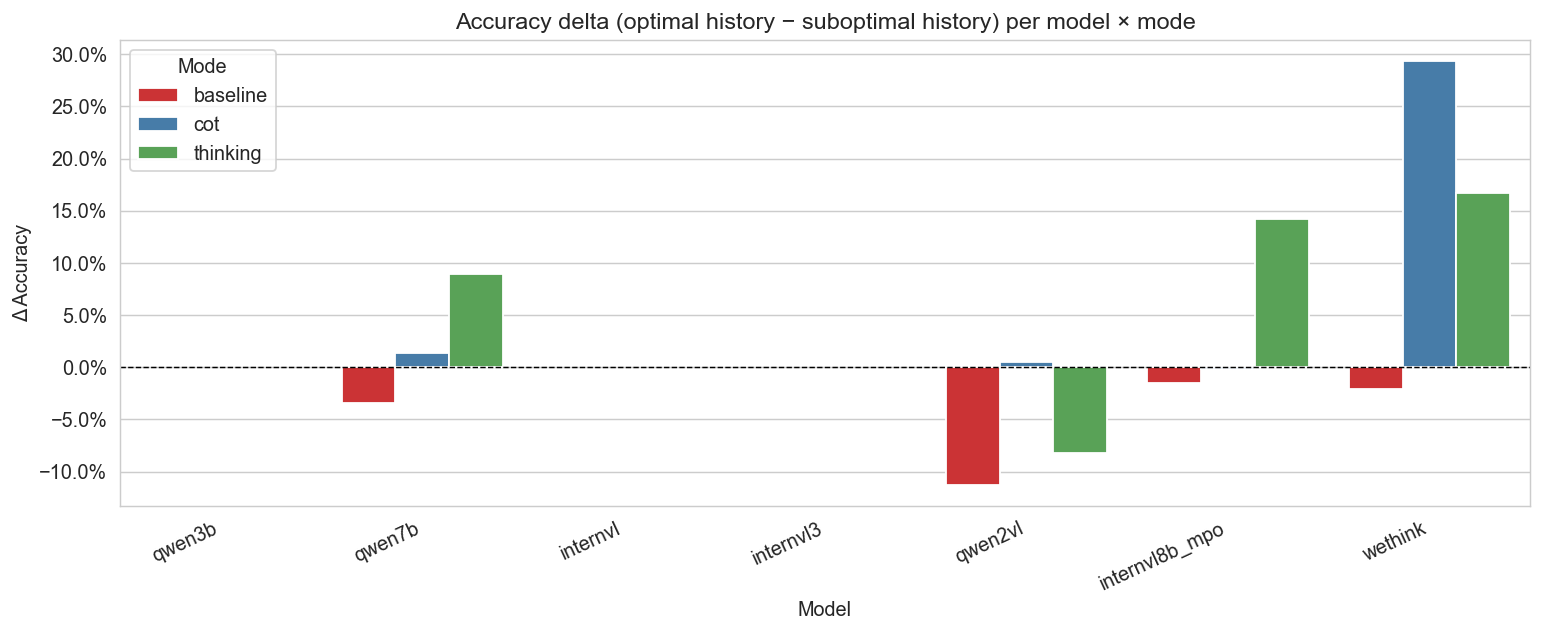

In [18]:
# Delta (optimal - suboptimal) per model and mode: does good history help?
pivot_delta = df.groupby(["model", "mode", "history_type"])["correct"].mean().unstack()
pivot_delta["delta"] = pivot_delta["optimal"] - pivot_delta["suboptimal"]
pivot_delta = pivot_delta.reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=pivot_delta, x="model", y="delta",
    hue="mode", hue_order=MODE_ORDER,
    order=MODEL_ORDER, palette="Set1", ax=ax
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Accuracy delta (optimal history − suboptimal history) per model × mode", fontsize=13)
ax.set_xlabel("Model")
ax.set_ylabel("Δ Accuracy")
ax.legend(title="Mode")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 3b. Effect of number of history images (0 / 3 / 5)

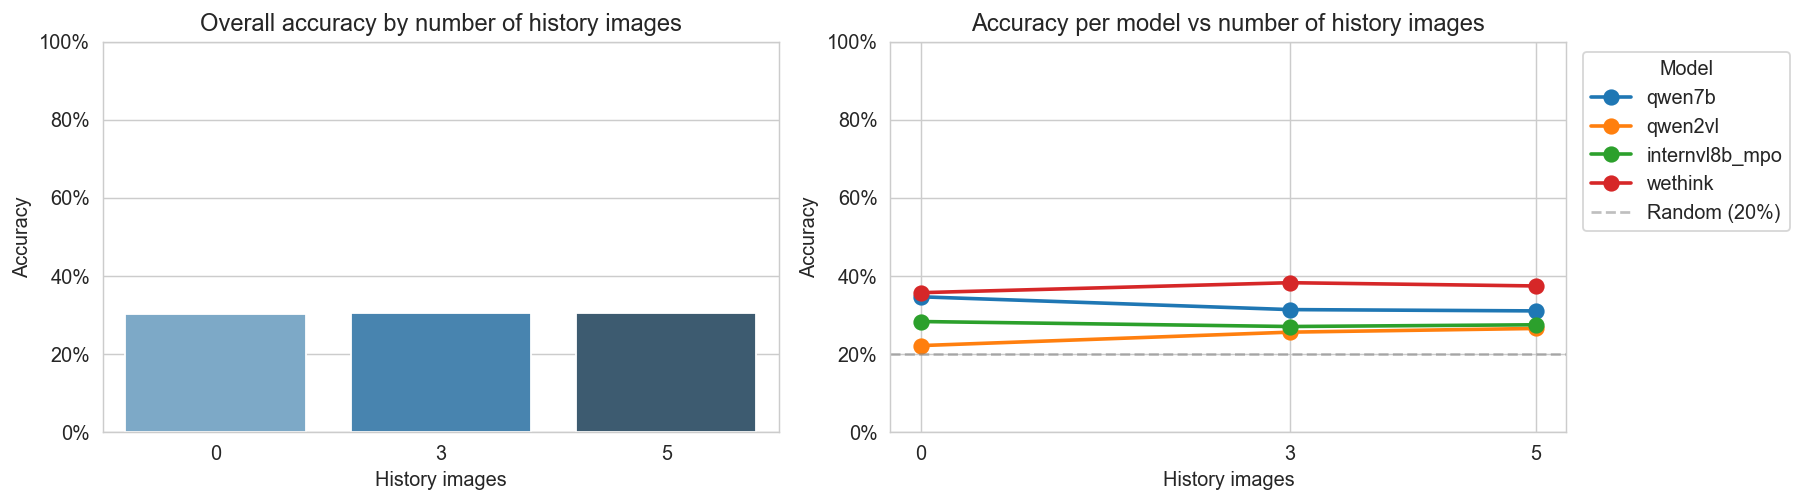

In [19]:
# Derive actual history_images values from data (robust to different run configs)
HIST_IMG = sorted(df["history_images"].unique())

# ── 1. Global accuracy per n_history ──────────────────────────────────────────
acc_nh = df.groupby("history_images")["correct"].mean().reindex(HIST_IMG)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(x=[str(h) for h in acc_nh.index], y=acc_nh.values, palette="Blues_d", ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title("Overall accuracy by number of history images")
axes[0].set_xlabel("History images")
axes[0].set_ylabel("Accuracy")

# ── 2. Per-model line plot ─────────────────────────────────────────────────────
acc_mnh = df.groupby(["model", "history_images"])["correct"].mean().reset_index()
present_models = [m for m in MODEL_ORDER if m in df["model"].unique()]
for model in present_models:
    sub = acc_mnh[acc_mnh["model"] == model].set_index("history_images").reindex(HIST_IMG)
    axes[1].plot(HIST_IMG, sub["correct"], marker="o", label=model, linewidth=2, markersize=8)

axes[1].axhline(1/5, color="gray", linestyle="--", alpha=0.5, label="Random (20%)")
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Accuracy per model vs number of history images")
axes[1].set_xlabel("History images")
axes[1].set_ylabel("Accuracy")
axes[1].set_xticks(HIST_IMG)
axes[1].legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()

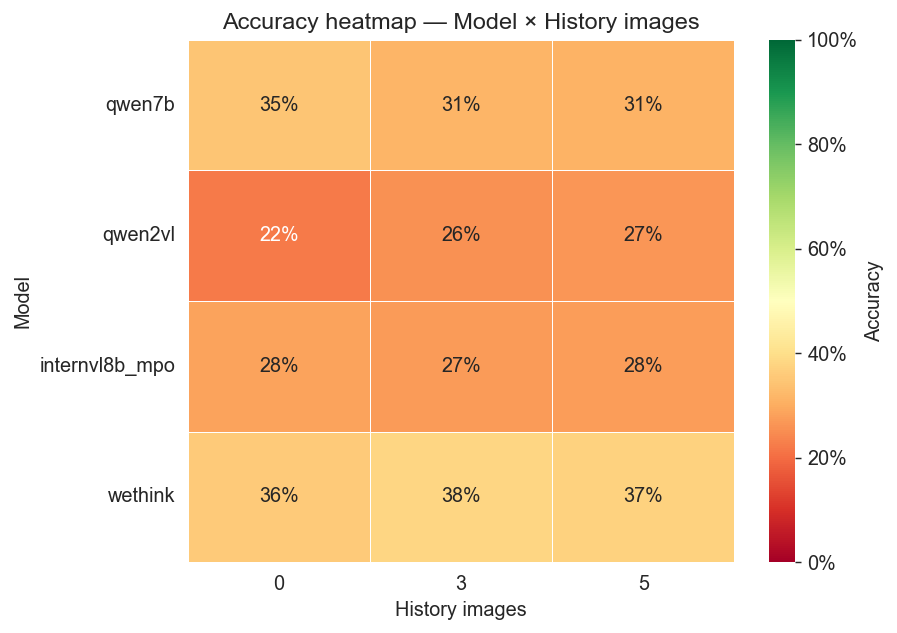

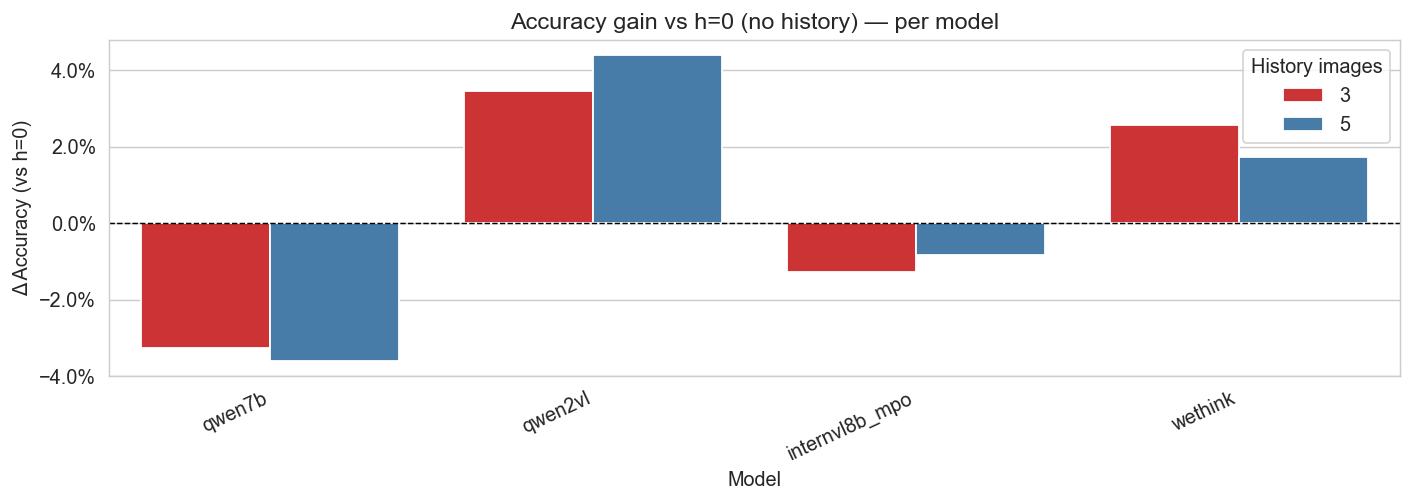

In [20]:
# ── 3. Heatmap model × n_history ──────────────────────────────────────────────
pivot_nh = df.groupby(["model", "history_images"])["correct"].mean().unstack()
pivot_nh = pivot_nh.reindex([m for m in MODEL_ORDER if m in pivot_nh.index]).reindex(columns=HIST_IMG)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    pivot_nh, annot=True, fmt=".0%", cmap="RdYlGn",
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
    cbar_kws={"label": "Accuracy", "format": mtick.PercentFormatter(1.0)}
)
ax.set_title("Accuracy heatmap — Model × History images", fontsize=13)
ax.set_xlabel("History images")
ax.set_ylabel("Model")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# ── 4. Delta vs h=0 per model ─────────────────────────────────────────────────
if 0 in HIST_IMG and len(HIST_IMG) > 1:
    baseline_h0 = pivot_nh[0]
    delta_df = pivot_nh.drop(columns=[0]).subtract(baseline_h0, axis=0)
    delta_melted = delta_df.reset_index().melt(
        id_vars="model", var_name="history_images", value_name="delta"
    )
    fig, ax = plt.subplots(figsize=(11, 4))
    sns.barplot(
        data=delta_melted, x="model", y="delta",
        hue="history_images",
        order=[m for m in MODEL_ORDER if m in delta_melted["model"].unique()],
        palette="Set1", ax=ax
    )
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title("Accuracy gain vs h=0 (no history) — per model", fontsize=13)
    ax.set_xlabel("Model")
    ax.set_ylabel("Δ Accuracy (vs h=0)")
    ax.legend(title="History images")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

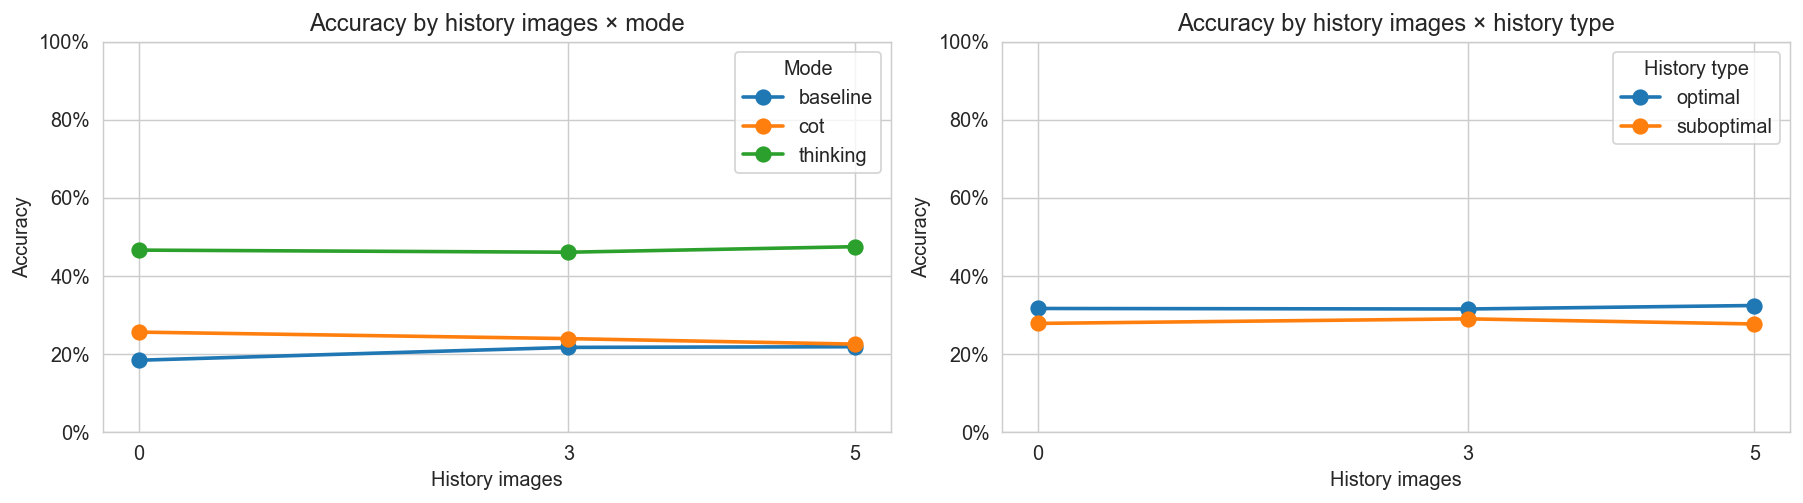

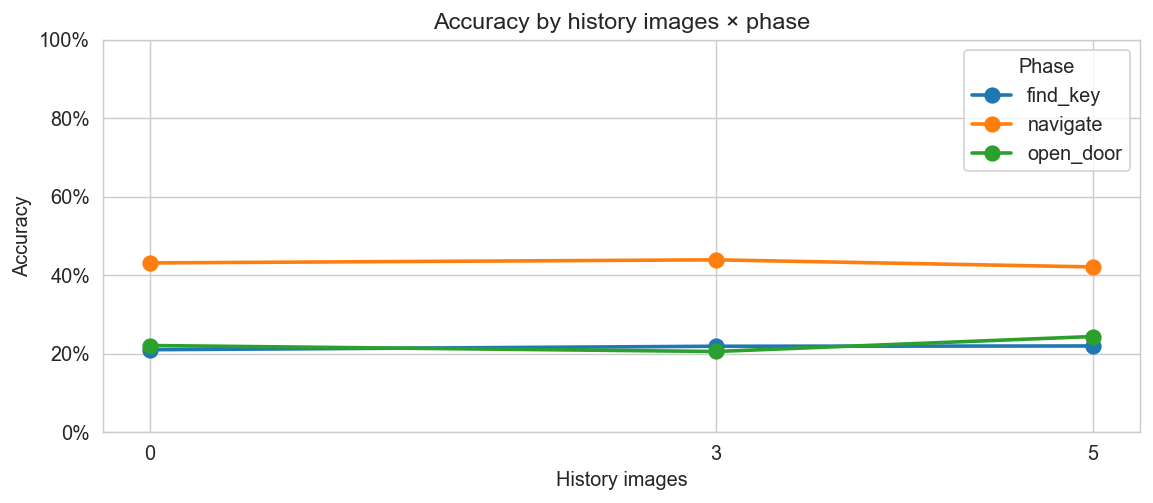

In [21]:
# ── 5. n_history × mode  +  n_history × history_type ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for mode in MODE_ORDER:
    sub = df[df["mode"] == mode].groupby("history_images")["correct"].mean().reindex(HIST_IMG)
    axes[0].plot(HIST_IMG, sub.values, marker="o", label=mode, linewidth=2, markersize=8)
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title("Accuracy by history images × mode")
axes[0].set_xlabel("History images")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(HIST_IMG)
axes[0].legend(title="Mode")

for ht in HIST_ORDER:
    sub = df[df["history_type"] == ht].groupby("history_images")["correct"].mean().reindex(HIST_IMG)
    axes[1].plot(HIST_IMG, sub.values, marker="o", label=ht, linewidth=2, markersize=8)
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Accuracy by history images × history type")
axes[1].set_xlabel("History images")
axes[1].set_ylabel("Accuracy")
axes[1].set_xticks(HIST_IMG)
axes[1].legend(title="History type")

plt.tight_layout()
plt.show()

# ── 6. n_history × phase ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
for phase in sorted(df["phase"].unique()):
    sub = df[df["phase"] == phase].groupby("history_images")["correct"].mean().reindex(HIST_IMG)
    ax.plot(HIST_IMG, sub.values, marker="o", label=phase, linewidth=2, markersize=8)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Accuracy by history images × phase", fontsize=13)
ax.set_xlabel("History images")
ax.set_ylabel("Accuracy")
ax.set_xticks(HIST_IMG)
ax.legend(title="Phase")
plt.tight_layout()
plt.show()

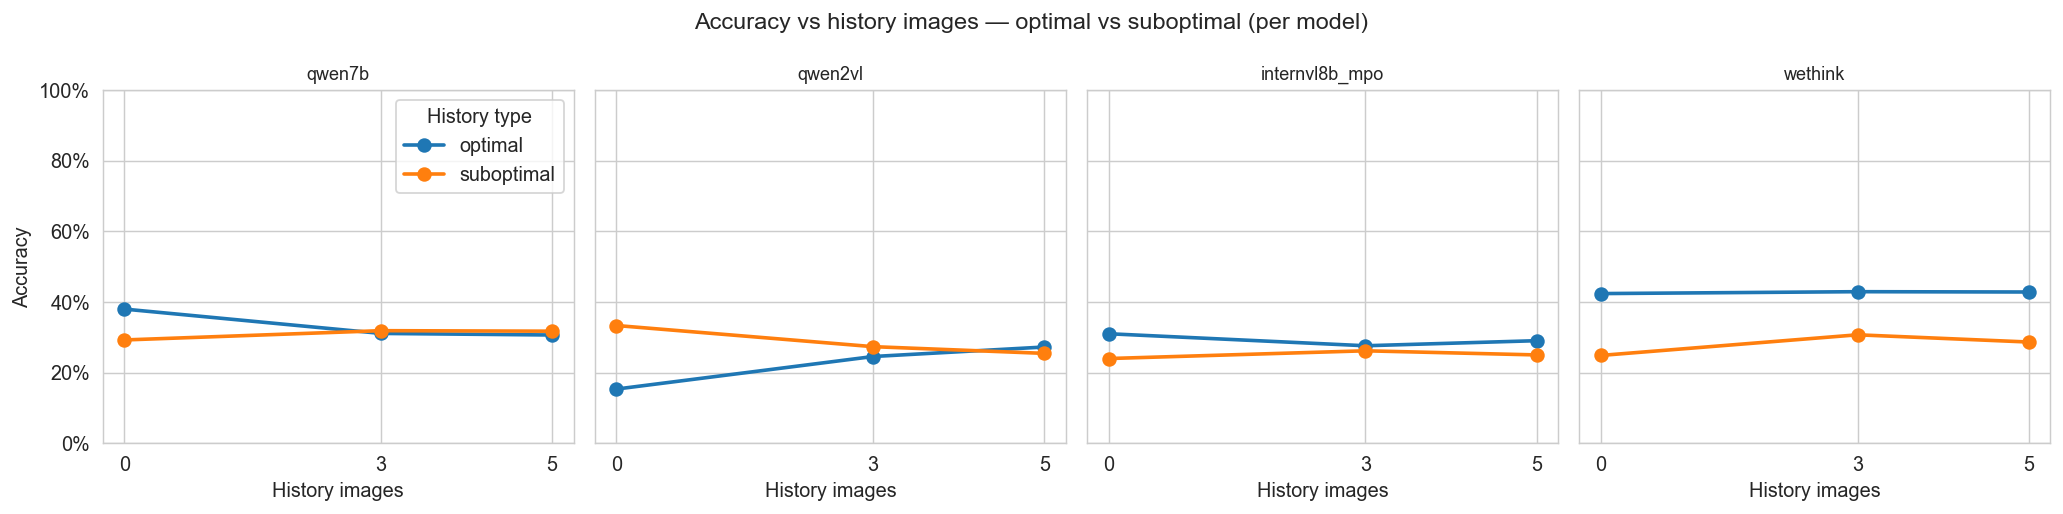

In [22]:
# ── 7. Interaction n_history × history_type × model ─────────────────────────
# For each model: does MORE history help more with OPTIMAL vs SUBOPTIMAL trajectories?
acc_mhht = df.groupby(["model", "history_images", "history_type"])["correct"].mean().reset_index()

fig, axes = plt.subplots(1, len(present_models), figsize=(4 * len(present_models), 4), sharey=True)
fig.suptitle("Accuracy vs history images — optimal vs suboptimal (per model)", fontsize=13)

for ax, model in zip(axes, present_models):
    for ht in HIST_ORDER:
        sub = acc_mhht[
            (acc_mhht["model"] == model) & (acc_mhht["history_type"] == ht)
        ].set_index("history_images").reindex(HIST_IMG)
        ax.plot(HIST_IMG, sub["correct"].values, marker="o", label=ht, linewidth=2, markersize=7)
    ax.set_title(model, fontsize=10)
    ax.set_xlabel("History images")
    ax.set_xticks(HIST_IMG)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    if ax == axes[0]:
        ax.set_ylabel("Accuracy")
        ax.legend(title="History type")

plt.tight_layout()
plt.show()

## 4. Accuracy per prompt variant

/var/folders/39/r4p5zsz16mx143m3kg8vwnsw0000gn/T/ipykernel_56008/3354420526.py:26: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/visu_project/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


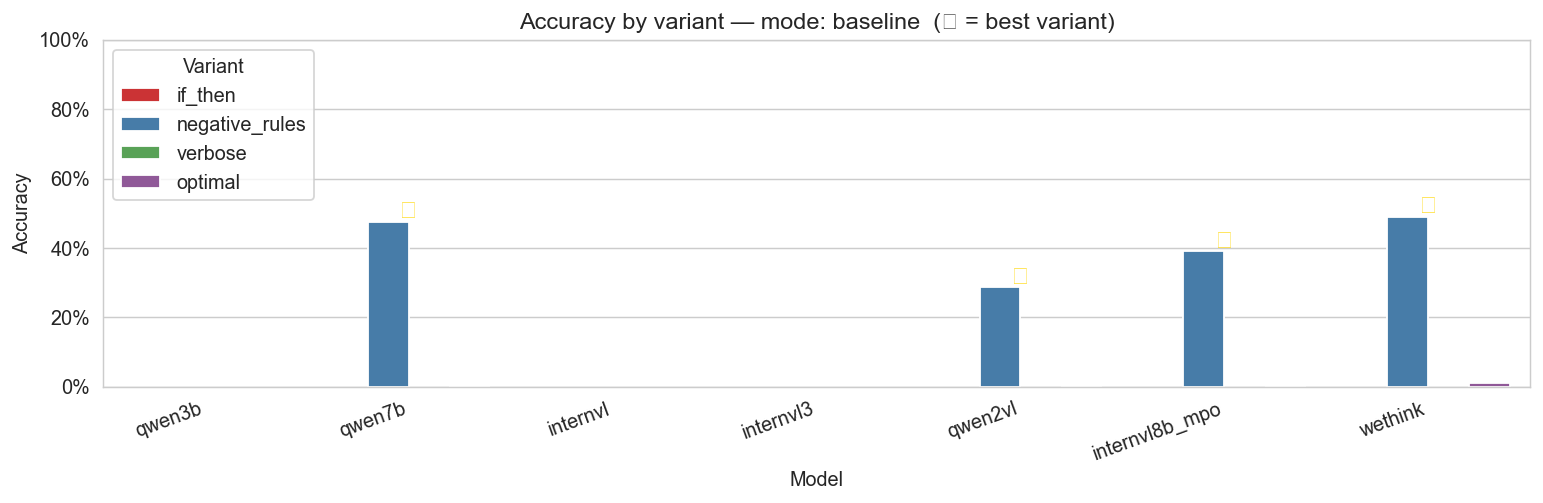

/var/folders/39/r4p5zsz16mx143m3kg8vwnsw0000gn/T/ipykernel_56008/3354420526.py:26: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/visu_project/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


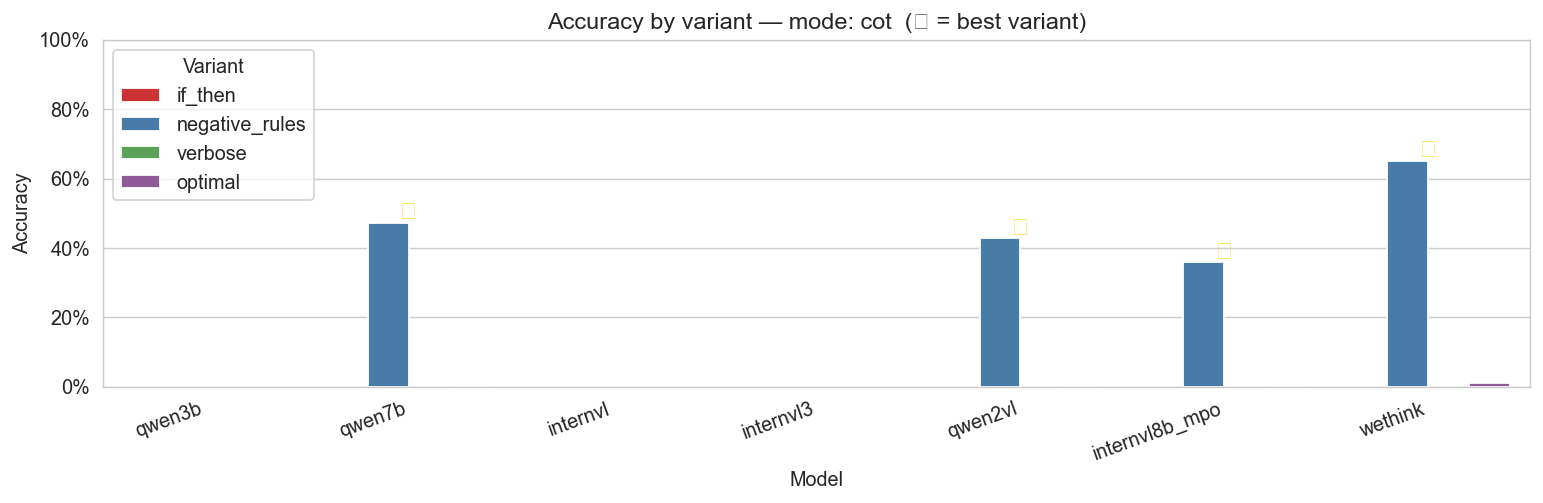

/var/folders/39/r4p5zsz16mx143m3kg8vwnsw0000gn/T/ipykernel_56008/3354420526.py:26: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/visu_project/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


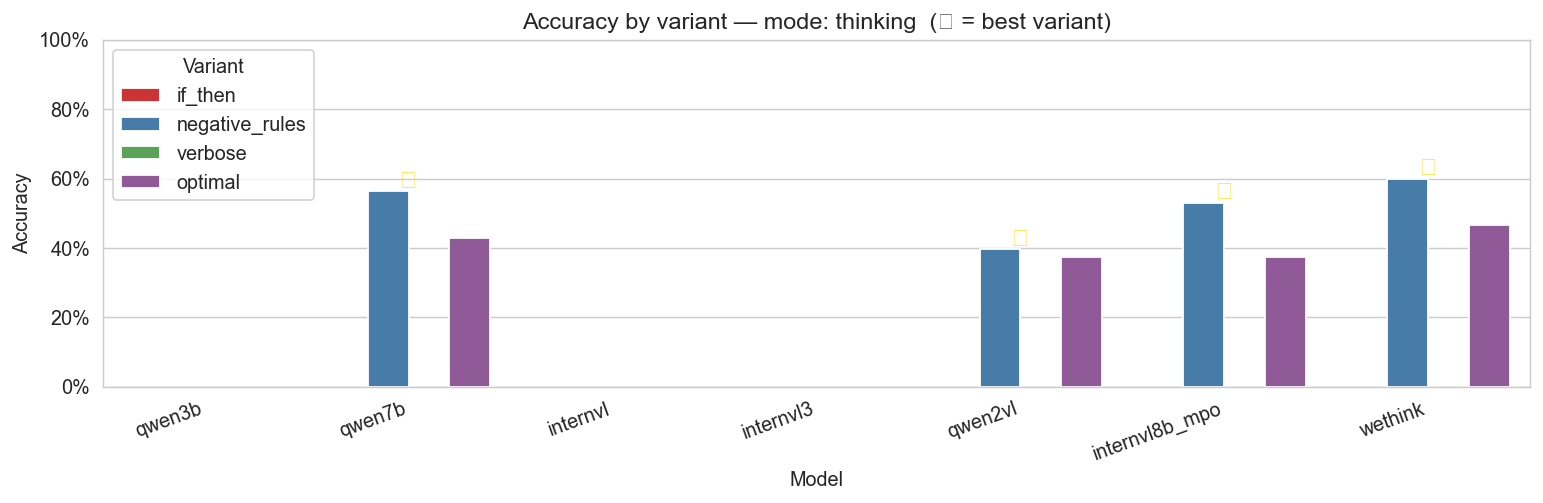

In [23]:
# Best variant per model (starred), split by mode
acc_vmm = df.groupby(["model", "variant", "mode"])["correct"].mean().reset_index()

for mode in MODE_ORDER:
    sub = acc_vmm[acc_vmm["mode"] == mode]
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.barplot(
        data=sub, x="model", y="correct",
        hue="variant", hue_order=VARIANT_ORDER,
        order=MODEL_ORDER, palette="Set1", ax=ax
    )
    # Mark best variant per model
    for model in MODEL_ORDER:
        msub = sub[sub["model"] == model]
        if len(msub):
            best = msub.loc[msub["correct"].idxmax()]
            x = MODEL_ORDER.index(model)
            ax.annotate("★", xy=(x, best["correct"] + 0.01), ha="center", fontsize=14, color="gold")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(f"Accuracy by variant — mode: {mode}  (★ = best variant)", fontsize=13)
    ax.set_xlabel("Model")
    ax.set_ylabel("Accuracy")
    ax.legend(title="Variant")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

## 5. Accuracy per environment and complexity

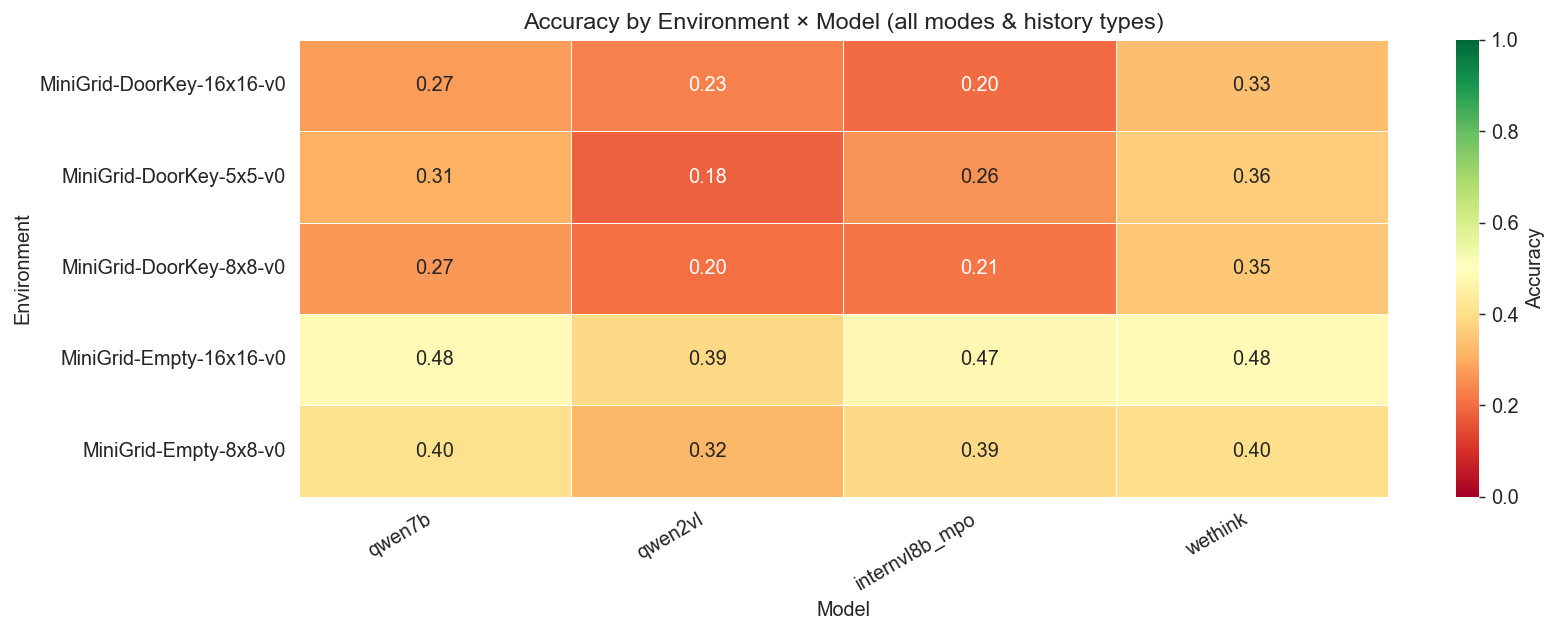

In [24]:
# Heatmap env × model (best mode per cell)
acc_env = df.groupby(["model", "env"])["correct"].mean().reset_index()
pivot_env = acc_env.pivot(index="env", columns="model", values="correct")
pivot_env = pivot_env.reindex(columns=[m for m in MODEL_ORDER if m in pivot_env.columns])

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    pivot_env, annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
    cbar_kws={"label": "Accuracy"}
)
ax.set_title("Accuracy by Environment × Model (all modes & history types)", fontsize=13)
ax.set_xlabel("Model")
ax.set_ylabel("Environment")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

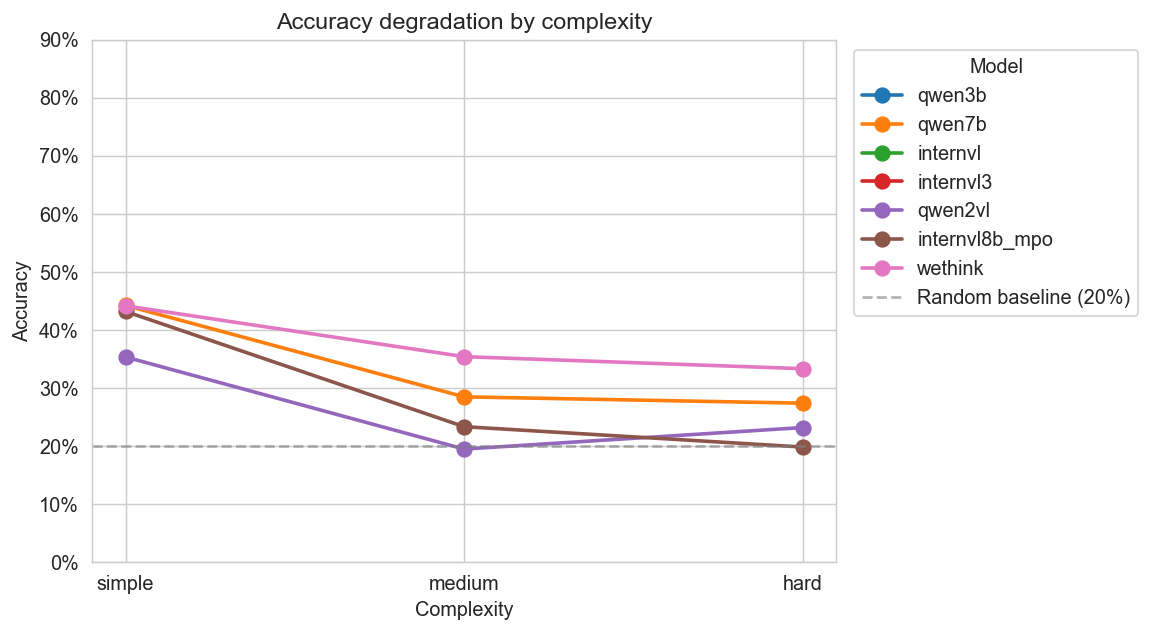

In [25]:
# Accuracy degradation by complexity, one line per model
acc_cplx = df.groupby(["model", "complexity"])["correct"].mean().reset_index()
complexity_order = [c for c in ["simple", "medium", "hard"] if c in df["complexity"].unique()]

fig, ax = plt.subplots(figsize=(9, 5))
for model in MODEL_ORDER:
    sub = acc_cplx[acc_cplx["model"] == model].set_index("complexity").reindex(complexity_order)
    ax.plot(complexity_order, sub["correct"], marker="o", label=model, linewidth=2, markersize=8)

ax.axhline(1/5, color="gray", linestyle="--", alpha=0.6, label="Random baseline (20%)")
ax.set_ylim(0, 0.9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Accuracy degradation by complexity", fontsize=13)
ax.set_xlabel("Complexity")
ax.set_ylabel("Accuracy")
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

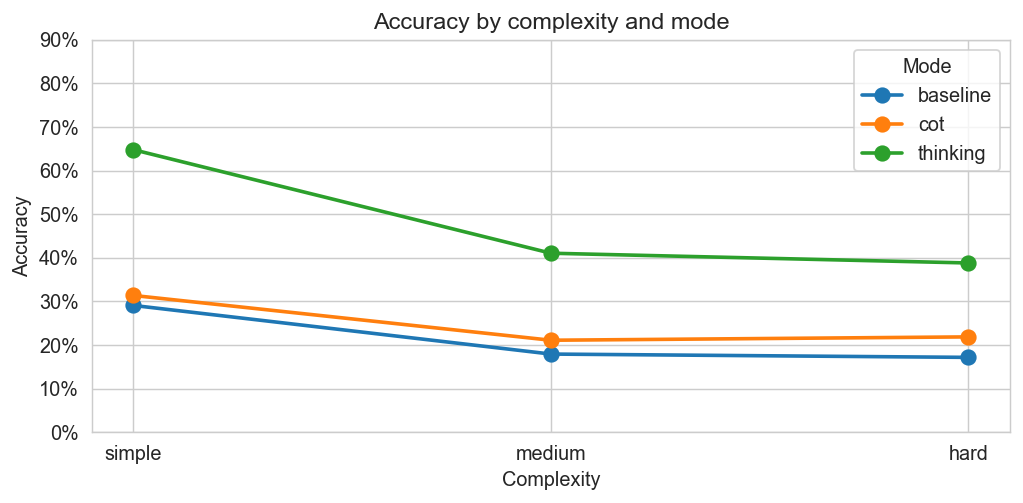

In [26]:
# Complexity × mode interaction
acc_cm = df.groupby(["mode", "complexity"])["correct"].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
for mode in MODE_ORDER:
    sub = acc_cm[acc_cm["mode"] == mode].set_index("complexity").reindex(complexity_order)
    ax.plot(complexity_order, sub["correct"], marker="o", label=mode, linewidth=2, markersize=8)

ax.set_ylim(0, 0.9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Accuracy by complexity and mode", fontsize=13)
ax.set_xlabel("Complexity")
ax.set_ylabel("Accuracy")
ax.legend(title="Mode")
plt.tight_layout()
plt.show()

## 6. Per-action analysis

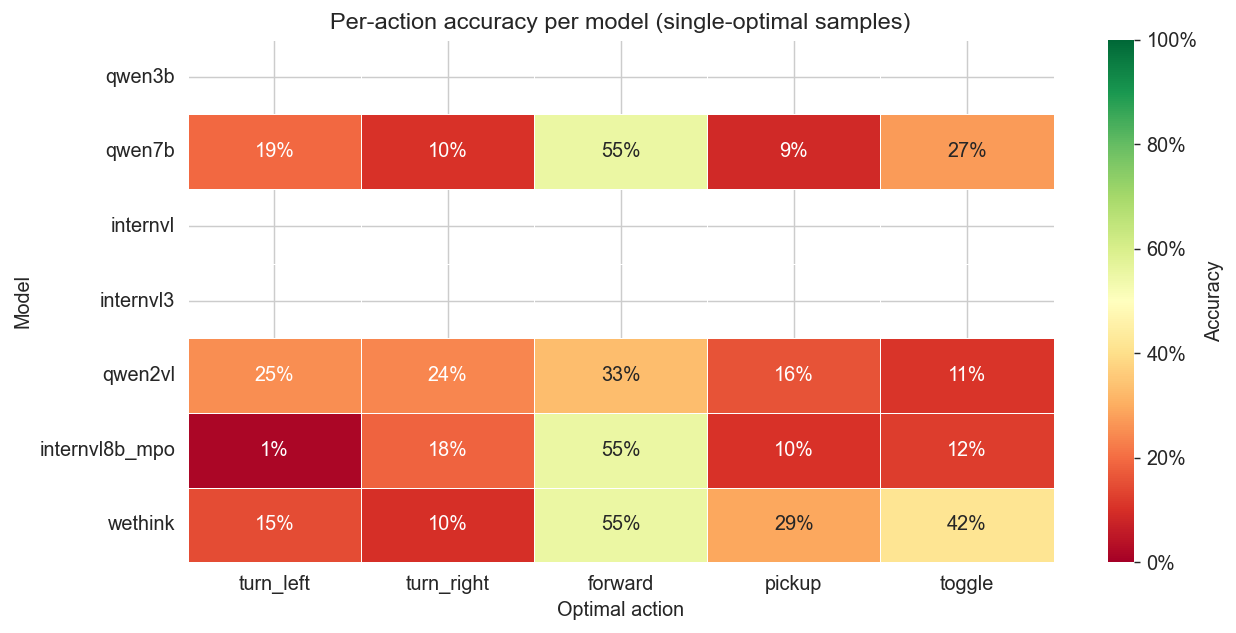

In [27]:
ACTION_LABELS  = ["turn_left", "turn_right", "forward", "pickup", "toggle"]
ACTION_INDICES = [0, 1, 2, 3, 5]

df_single = df[df["opt_list"].apply(len) == 1].copy()
df_single["optimal_action"] = df_single["opt_list"].apply(lambda x: x[0])
df_single["optimal_label"]  = df_single["optimal_action"].map(ACTION_MAP)

# Per-action accuracy per model
acc_am = df_single.groupby(["model", "optimal_label"])["correct"].mean().reset_index()

pivot_am = acc_am.pivot(index="model", columns="optimal_label", values="correct")
pivot_am = pivot_am.reindex(MODEL_ORDER)[ACTION_LABELS]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot_am, annot=True, fmt=".0%", cmap="RdYlGn",
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
    cbar_kws={"label": "Accuracy", "format": mtick.PercentFormatter(1.0)}
)
ax.set_title("Per-action accuracy per model (single-optimal samples)", fontsize=13)
ax.set_xlabel("Optimal action")
ax.set_ylabel("Model")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

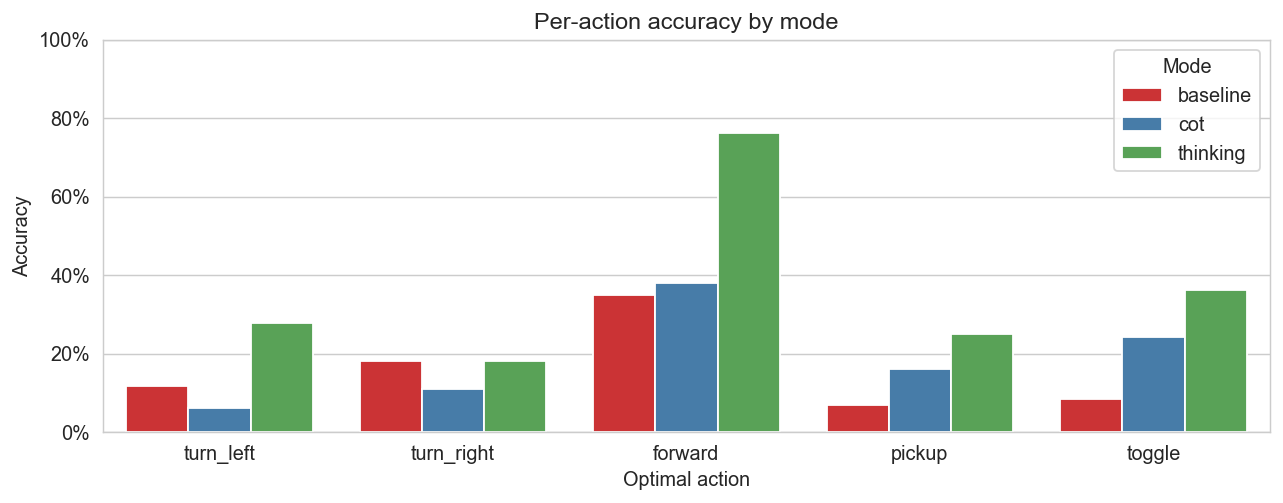

In [28]:
# Per-action accuracy broken down by mode
acc_amode = df_single.groupby(["mode", "optimal_label"])["correct"].mean().reset_index()

plt.figure(figsize=(10, 4))
sns.barplot(
    data=acc_amode, x="optimal_label", y="correct",
    hue="mode", hue_order=MODE_ORDER,
    order=ACTION_LABELS, palette="Set1"
)
plt.ylim(0, 1)
plt.title("Per-action accuracy by mode", fontsize=13)
plt.ylabel("Accuracy")
plt.xlabel("Optimal action")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend(title="Mode")
plt.tight_layout()
plt.show()

## 7. Confusion matrices per model × mode

/var/folders/39/r4p5zsz16mx143m3kg8vwnsw0000gn/T/ipykernel_56008/2096589413.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm  = np.where(row_sums > 0, cm / row_sums, 0)
/var/folders/39/r4p5zsz16mx143m3kg8vwnsw0000gn/T/ipykernel_56008/2096589413.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm  = np.where(row_sums > 0, cm / row_sums, 0)
/var/folders/39/r4p5zsz16mx143m3kg8vwnsw0000gn/T/ipykernel_56008/2096589413.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm  = np.where(row_sums > 0, cm / row_sums, 0)


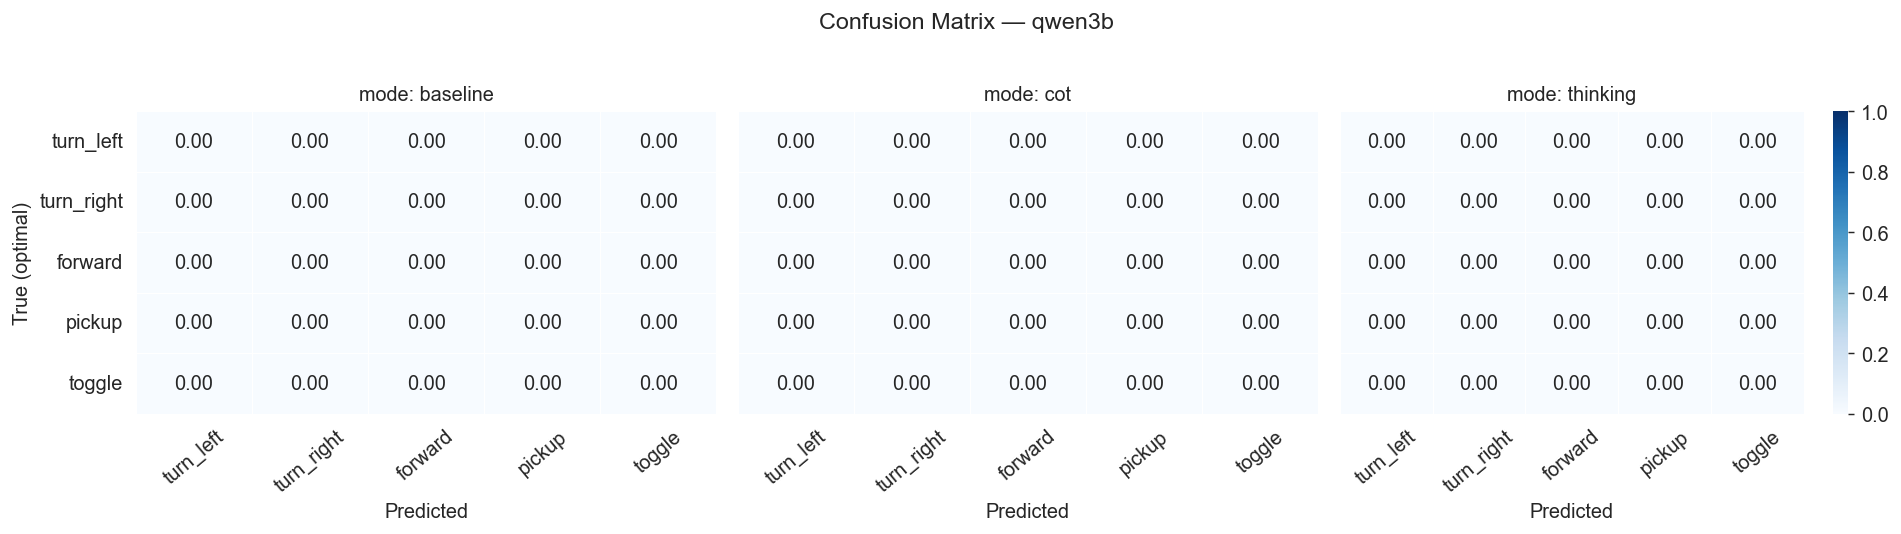

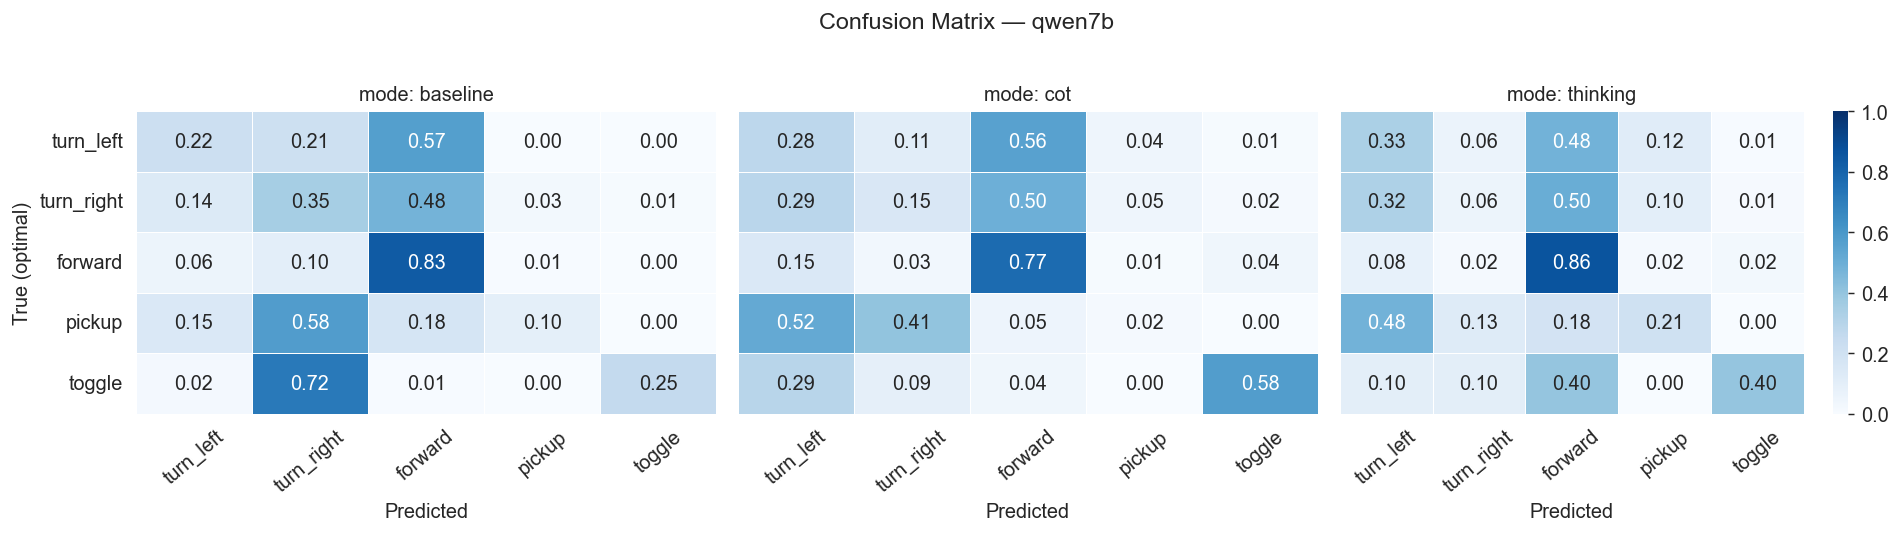

/var/folders/39/r4p5zsz16mx143m3kg8vwnsw0000gn/T/ipykernel_56008/2096589413.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm  = np.where(row_sums > 0, cm / row_sums, 0)
/var/folders/39/r4p5zsz16mx143m3kg8vwnsw0000gn/T/ipykernel_56008/2096589413.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm  = np.where(row_sums > 0, cm / row_sums, 0)
/var/folders/39/r4p5zsz16mx143m3kg8vwnsw0000gn/T/ipykernel_56008/2096589413.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm  = np.where(row_sums > 0, cm / row_sums, 0)


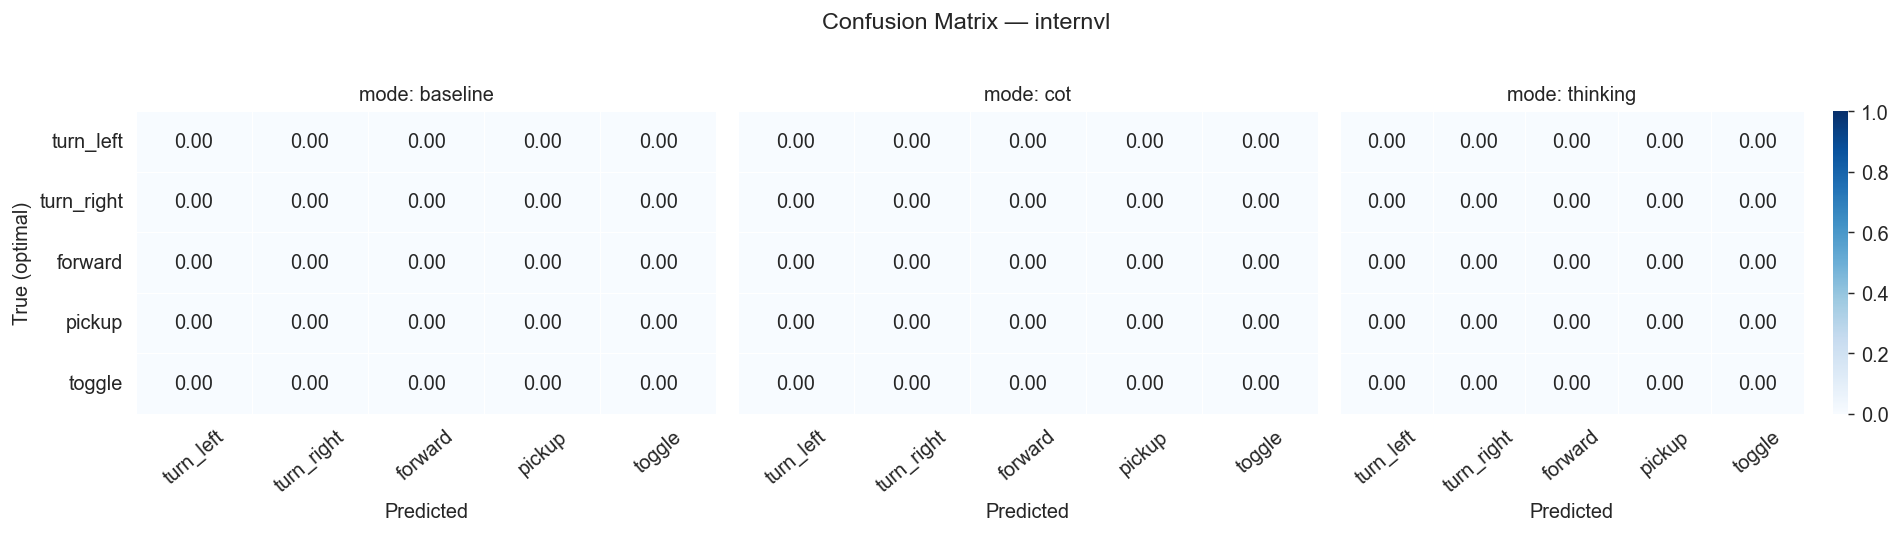

/var/folders/39/r4p5zsz16mx143m3kg8vwnsw0000gn/T/ipykernel_56008/2096589413.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm  = np.where(row_sums > 0, cm / row_sums, 0)
/var/folders/39/r4p5zsz16mx143m3kg8vwnsw0000gn/T/ipykernel_56008/2096589413.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm  = np.where(row_sums > 0, cm / row_sums, 0)
/var/folders/39/r4p5zsz16mx143m3kg8vwnsw0000gn/T/ipykernel_56008/2096589413.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm  = np.where(row_sums > 0, cm / row_sums, 0)


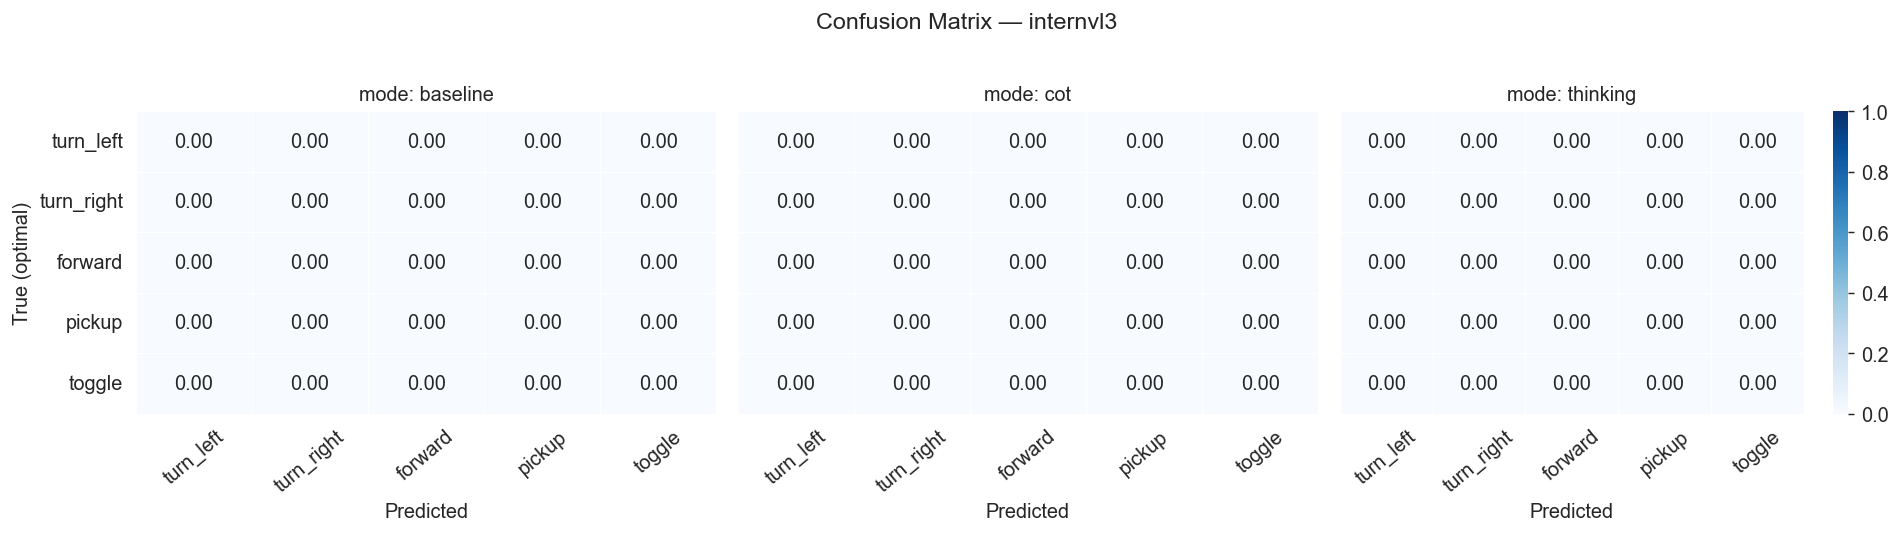

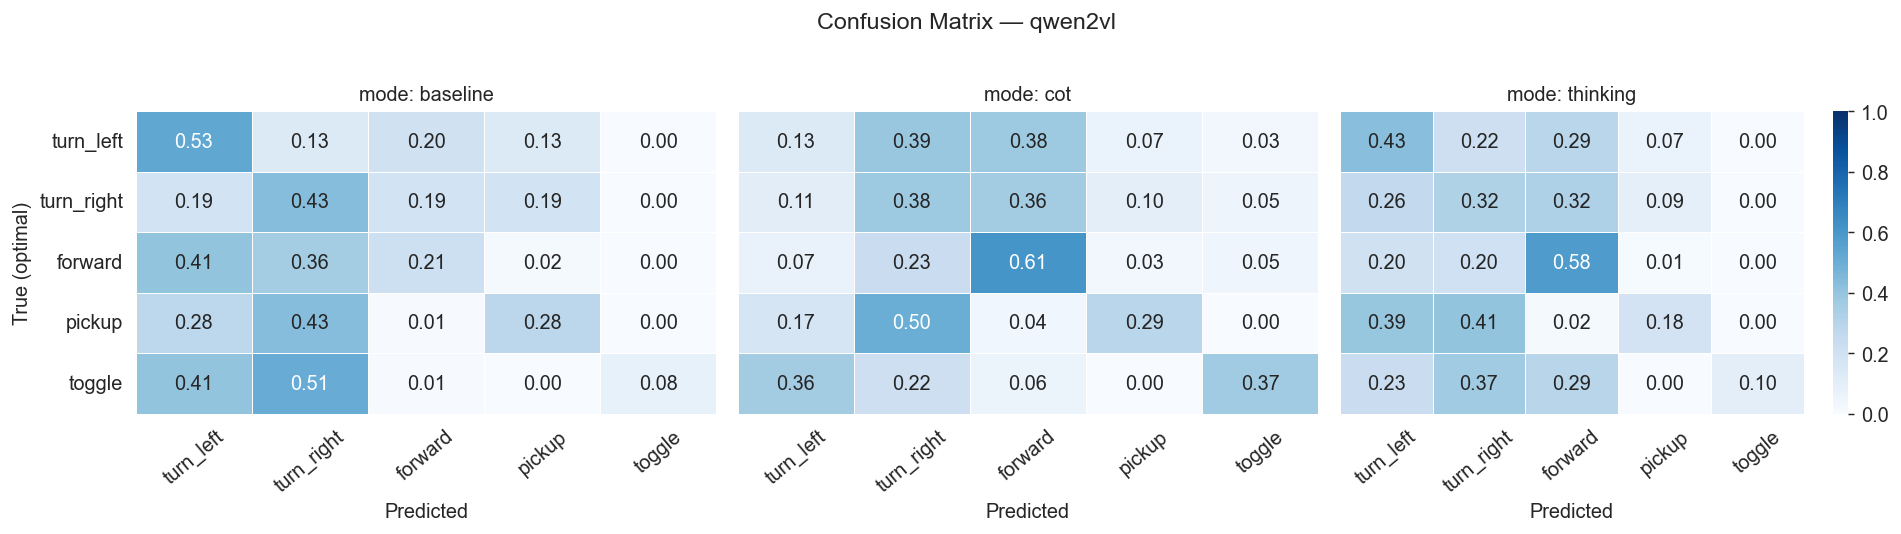

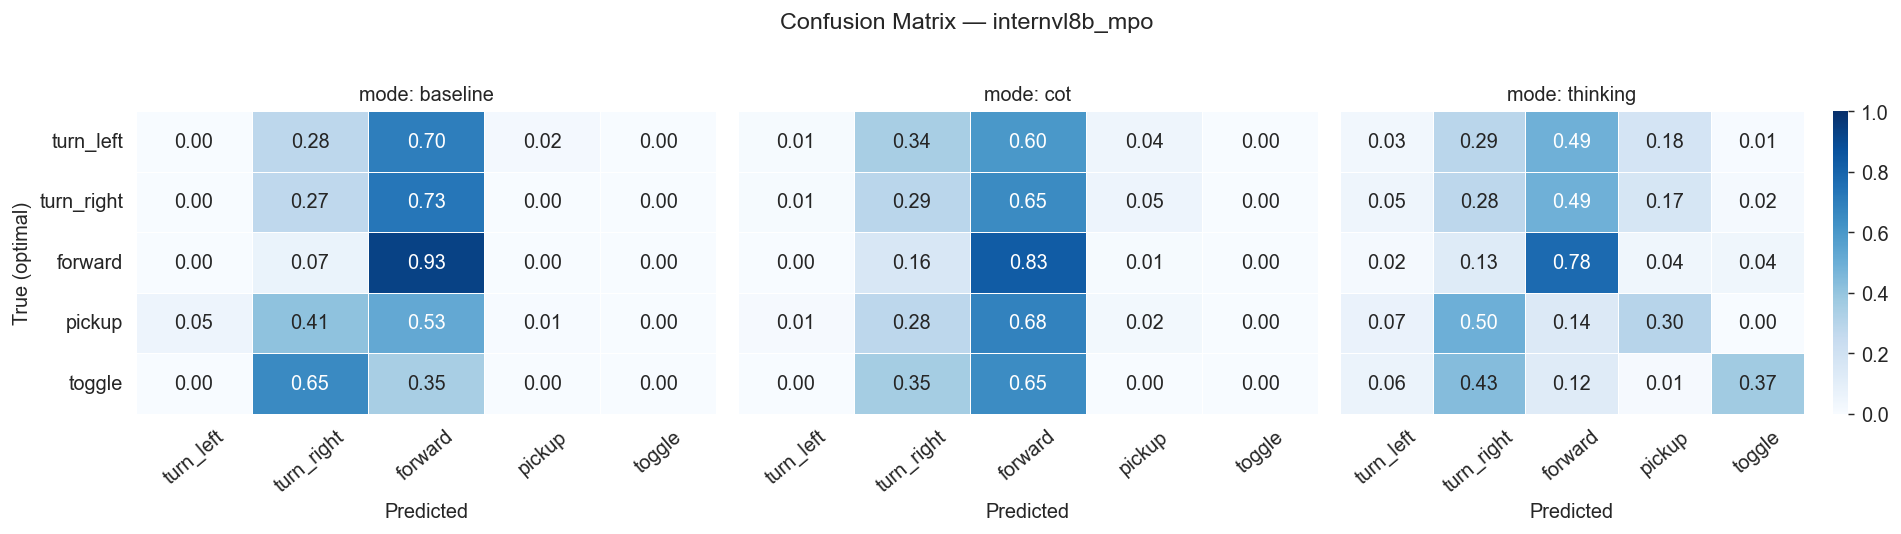

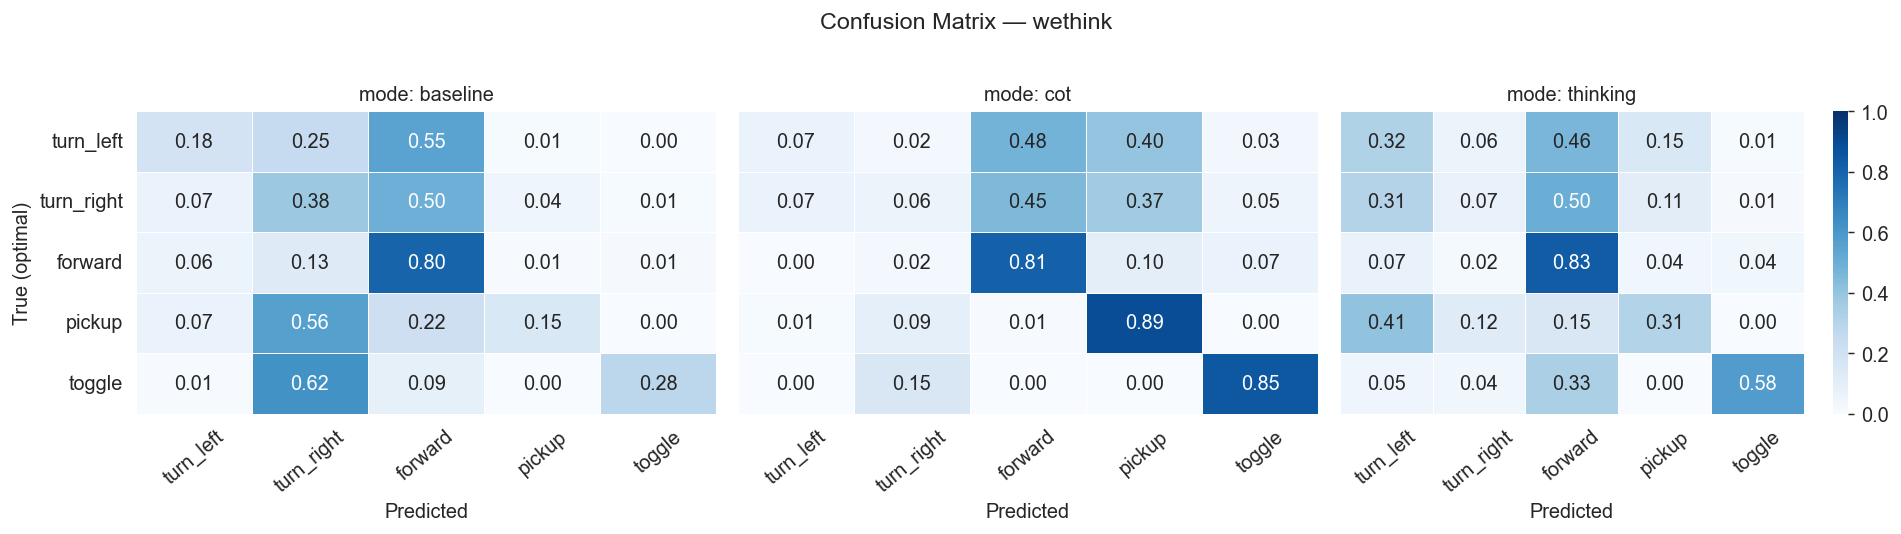

In [29]:
# One figure per model; columns = modes
for model in MODEL_ORDER:
    fig, axes = plt.subplots(1, len(MODE_ORDER), figsize=(15, 4), sharey=True)
    fig.suptitle(f"Confusion Matrix — {model}", fontsize=13, y=1.02)

    for ax, mode in zip(axes, MODE_ORDER):
        sub = df_single[
            (df_single["model"] == model) &
            (df_single["mode"] == mode) &
            (df_single["predicted_action"].notna())   # ← ajouter cette ligne
]
        cm = np.zeros((len(ACTION_INDICES), len(ACTION_INDICES)), dtype=int)
        for _, row in sub.iterrows():
            true_idx = ACTION_INDICES.index(row["optimal_action"])
            pred_val = int(row["predicted_action"])
            if pred_val in ACTION_INDICES:
                pred_idx = ACTION_INDICES.index(pred_val)
                cm[true_idx, pred_idx] += 1

        row_sums = cm.sum(axis=1, keepdims=True)
        cm_norm  = np.where(row_sums > 0, cm / row_sums, 0)

        sns.heatmap(
            cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=ACTION_LABELS, yticklabels=ACTION_LABELS,
            ax=ax, cbar=(mode == MODE_ORDER[-1]), linewidths=0.4,
        )
        ax.set_title(f"mode: {mode}", fontsize=11)
        ax.set_xlabel("Predicted")
        if mode == MODE_ORDER[0]:
            ax.set_ylabel("True (optimal)")
        ax.tick_params(axis="x", rotation=40)
        ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    plt.show()

/var/folders/39/r4p5zsz16mx143m3kg8vwnsw0000gn/T/ipykernel_56008/578129370.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm  = np.where(row_sums > 0, cm / row_sums, 0)
/var/folders/39/r4p5zsz16mx143m3kg8vwnsw0000gn/T/ipykernel_56008/578129370.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm  = np.where(row_sums > 0, cm / row_sums, 0)


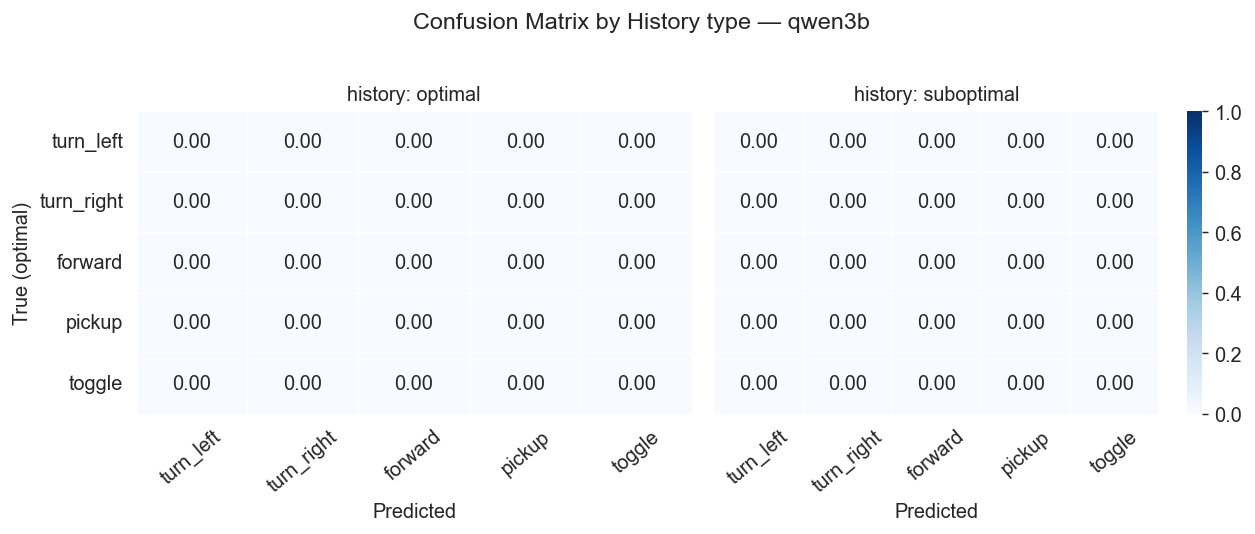

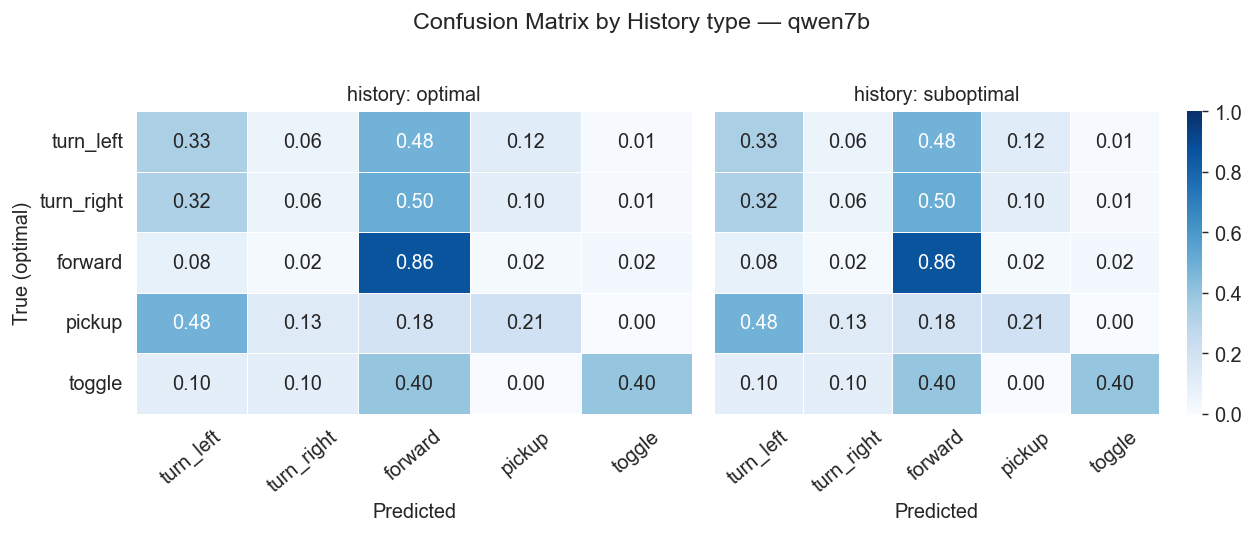

/var/folders/39/r4p5zsz16mx143m3kg8vwnsw0000gn/T/ipykernel_56008/578129370.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm  = np.where(row_sums > 0, cm / row_sums, 0)
/var/folders/39/r4p5zsz16mx143m3kg8vwnsw0000gn/T/ipykernel_56008/578129370.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm  = np.where(row_sums > 0, cm / row_sums, 0)


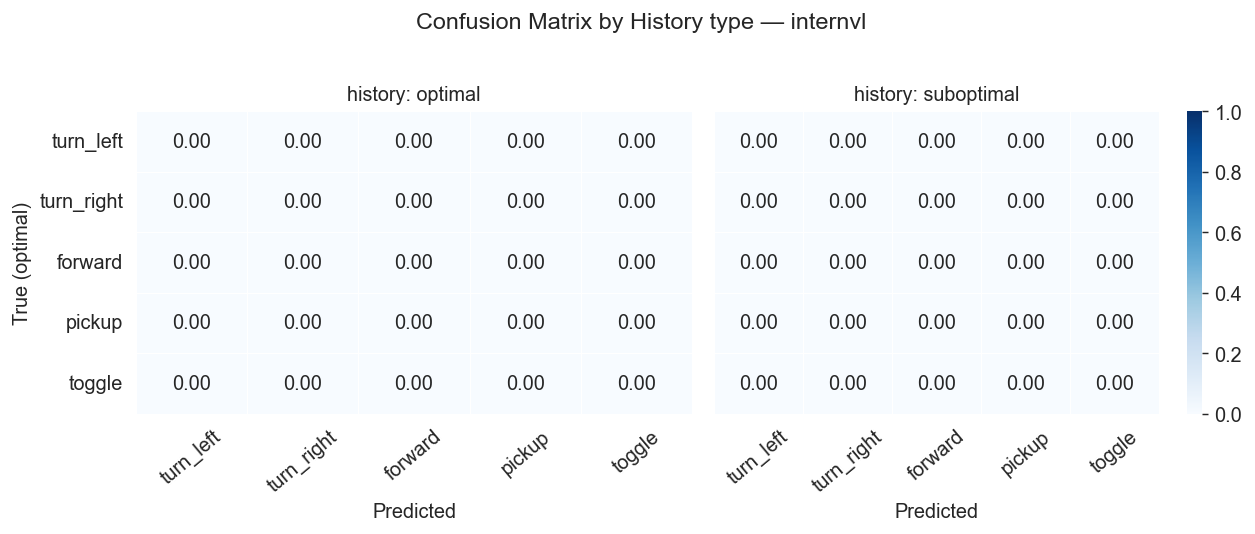

/var/folders/39/r4p5zsz16mx143m3kg8vwnsw0000gn/T/ipykernel_56008/578129370.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm  = np.where(row_sums > 0, cm / row_sums, 0)
/var/folders/39/r4p5zsz16mx143m3kg8vwnsw0000gn/T/ipykernel_56008/578129370.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm  = np.where(row_sums > 0, cm / row_sums, 0)


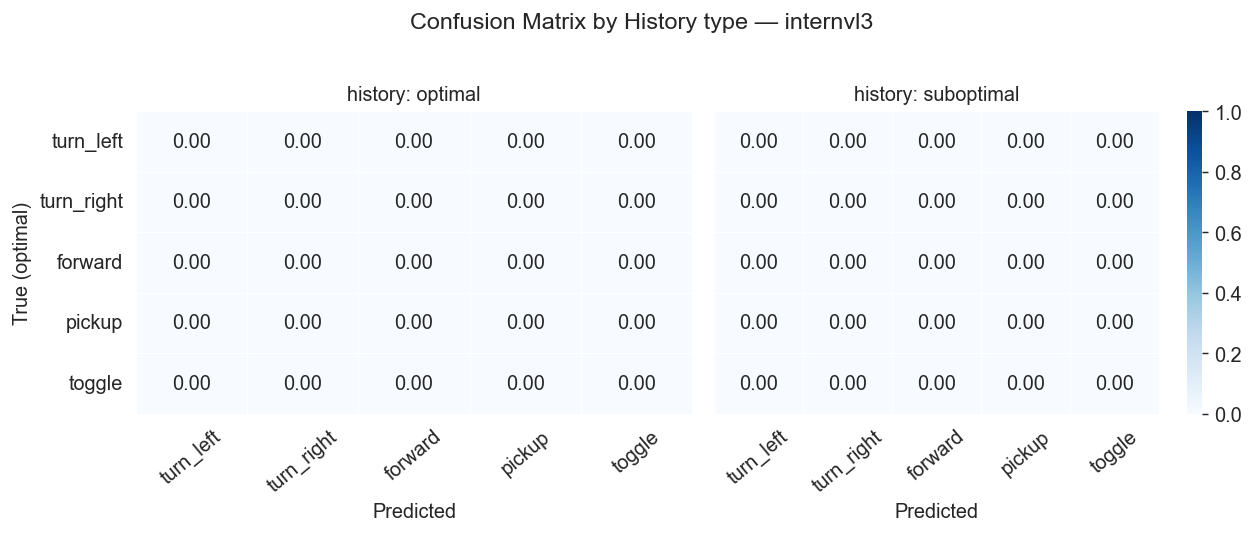

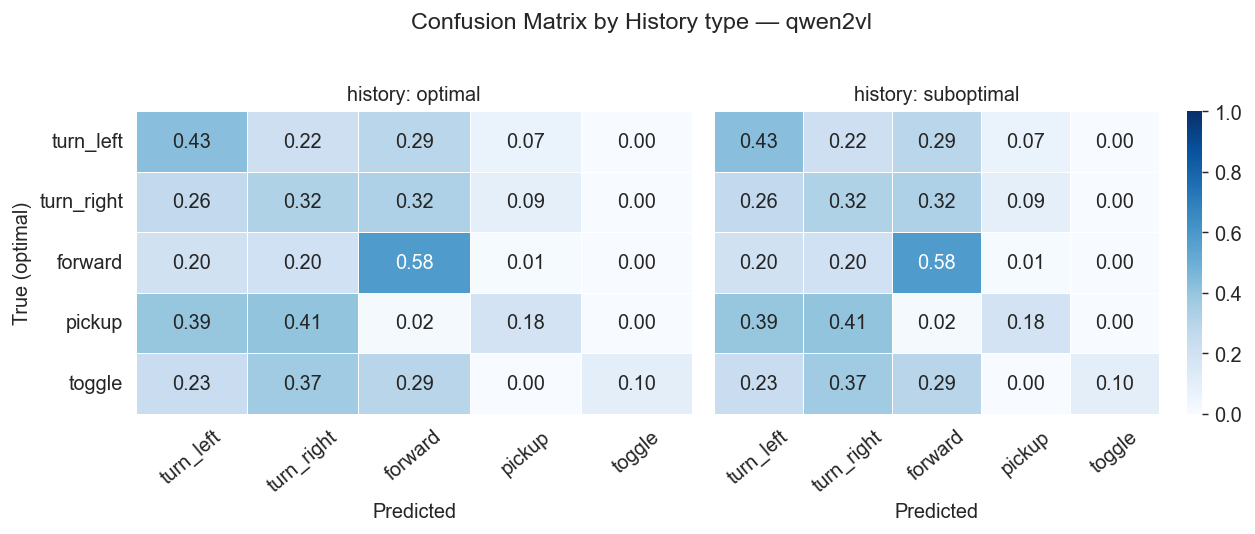

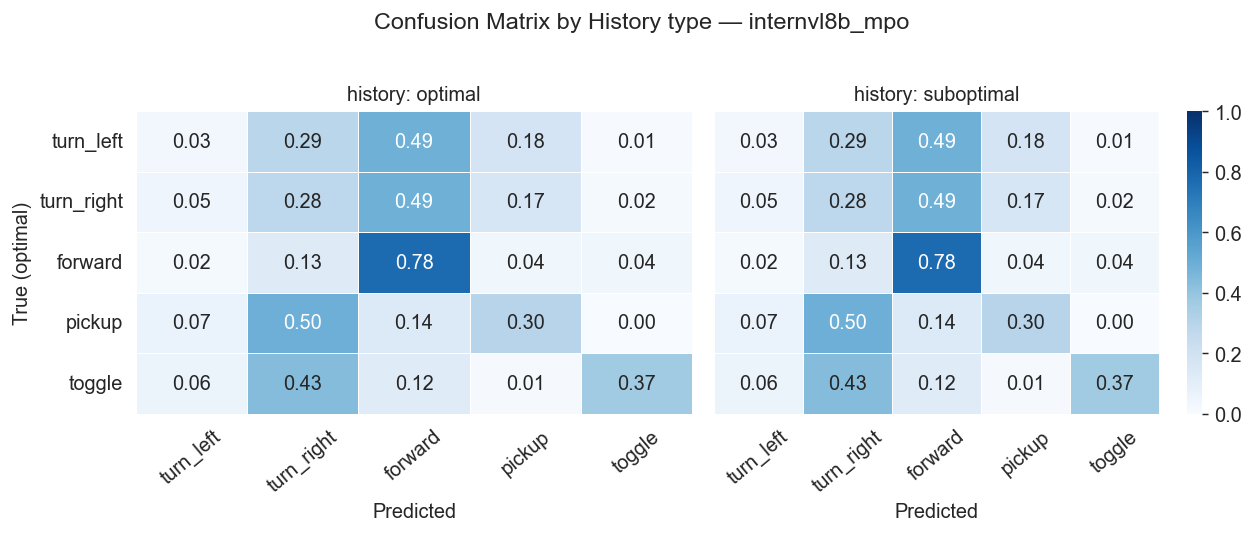

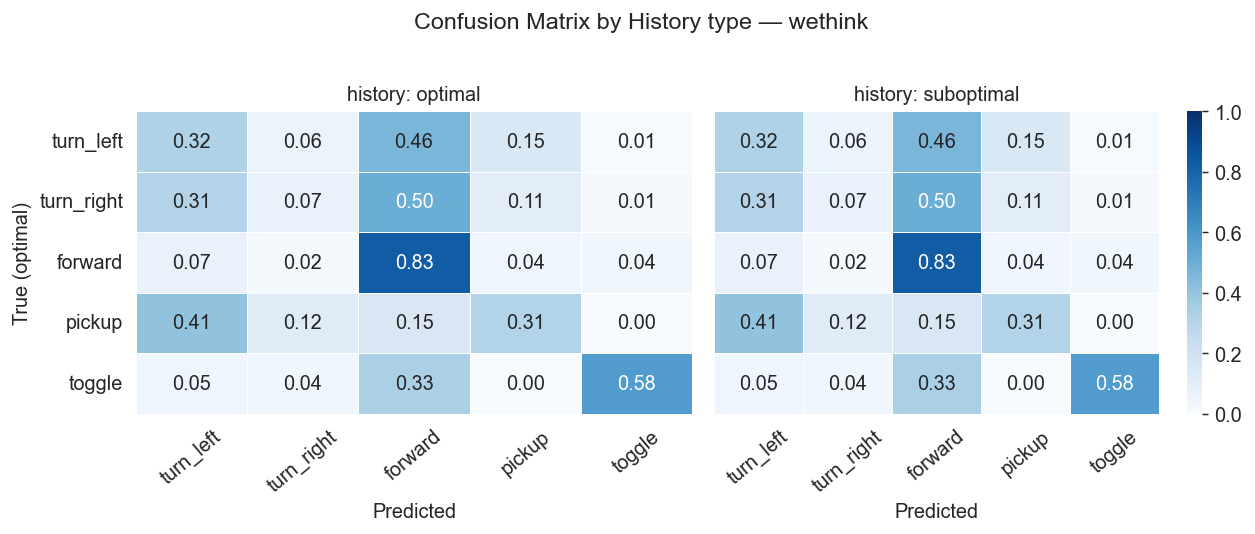

In [30]:
# Confusion matrices per model × history_type
for model in MODEL_ORDER:
    fig, axes = plt.subplots(1, len(HIST_ORDER), figsize=(10, 4), sharey=True)
    fig.suptitle(f"Confusion Matrix by History type — {model}", fontsize=13, y=1.02)

    for ax, hist in zip(axes, HIST_ORDER):
        sub = df_single[
            (df_single["model"] == model) &
            (df_single["mode"] == mode) &
            (df_single["predicted_action"].notna())   # ← ajouter cette ligne
        ]
        cm = np.zeros((len(ACTION_INDICES), len(ACTION_INDICES)), dtype=int)
        for _, row in sub.iterrows():
            true_idx = ACTION_INDICES.index(row["optimal_action"])
            pred_val = int(row["predicted_action"])
            if pred_val in ACTION_INDICES:
                pred_idx = ACTION_INDICES.index(pred_val)
                cm[true_idx, pred_idx] += 1

        row_sums = cm.sum(axis=1, keepdims=True)
        cm_norm  = np.where(row_sums > 0, cm / row_sums, 0)

        sns.heatmap(
            cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=ACTION_LABELS, yticklabels=ACTION_LABELS,
            ax=ax, cbar=(hist == HIST_ORDER[-1]), linewidths=0.4,
        )
        ax.set_title(f"history: {hist}", fontsize=11)
        ax.set_xlabel("Predicted")
        if hist == HIST_ORDER[0]:
            ax.set_ylabel("True (optimal)")
        ax.tick_params(axis="x", rotation=40)
        ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    plt.show()

## 8. Wrong prediction distributions

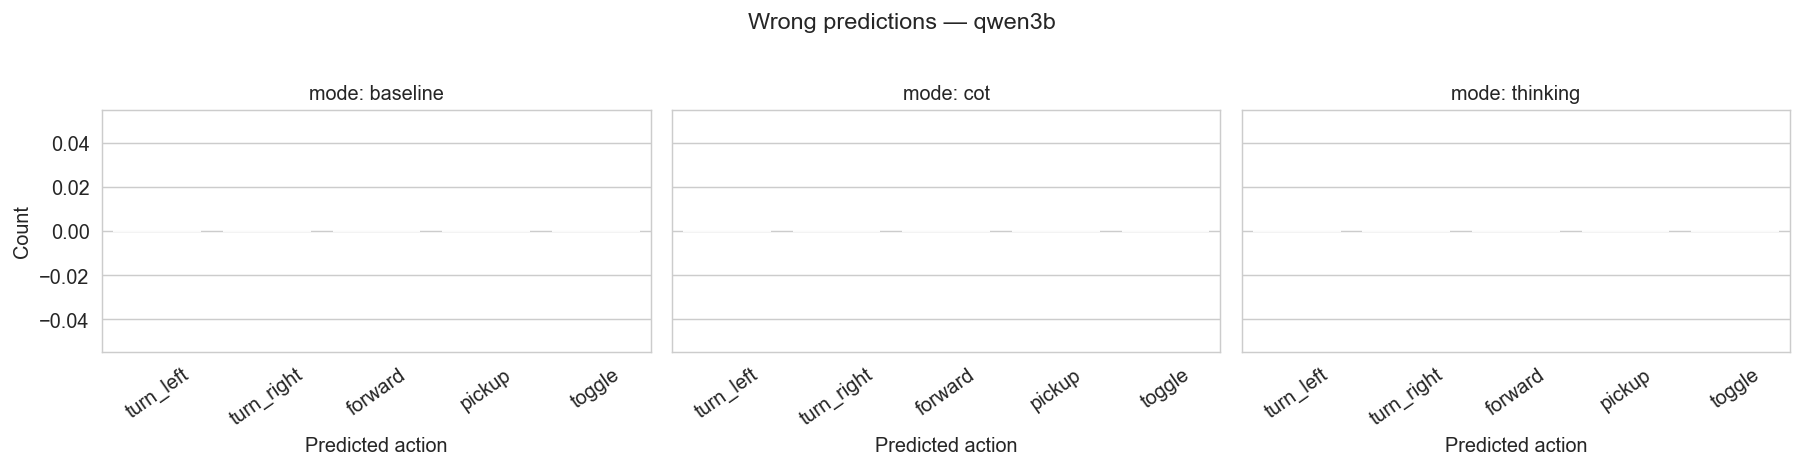

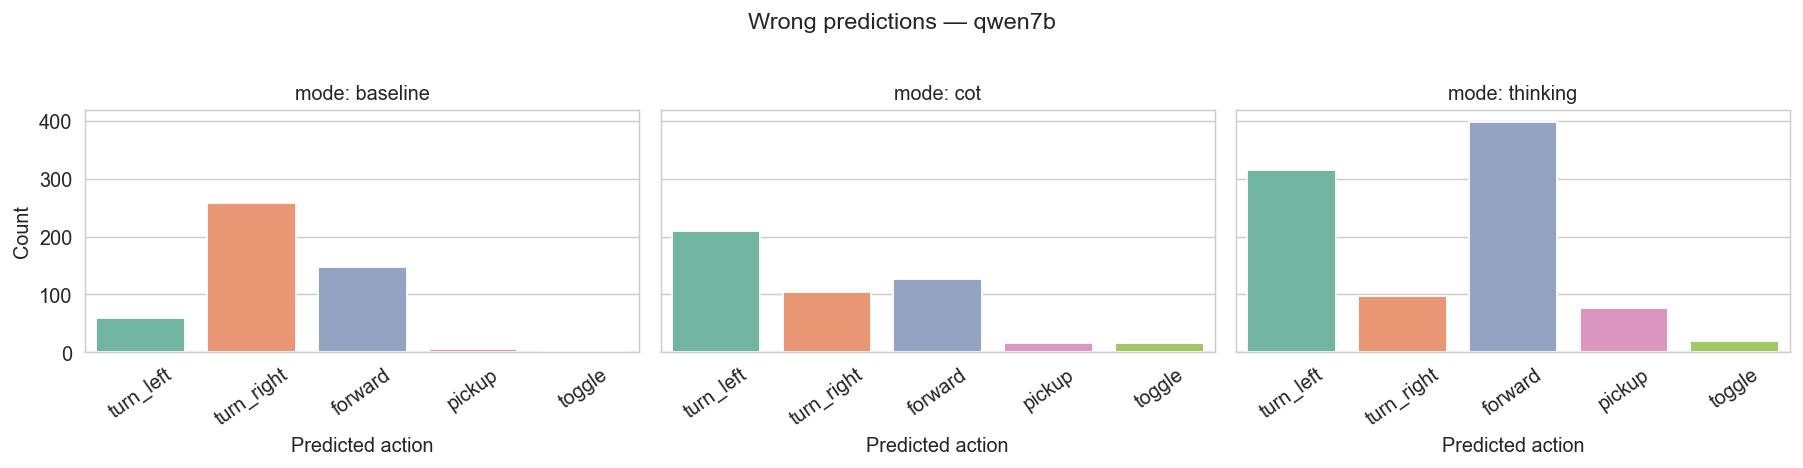

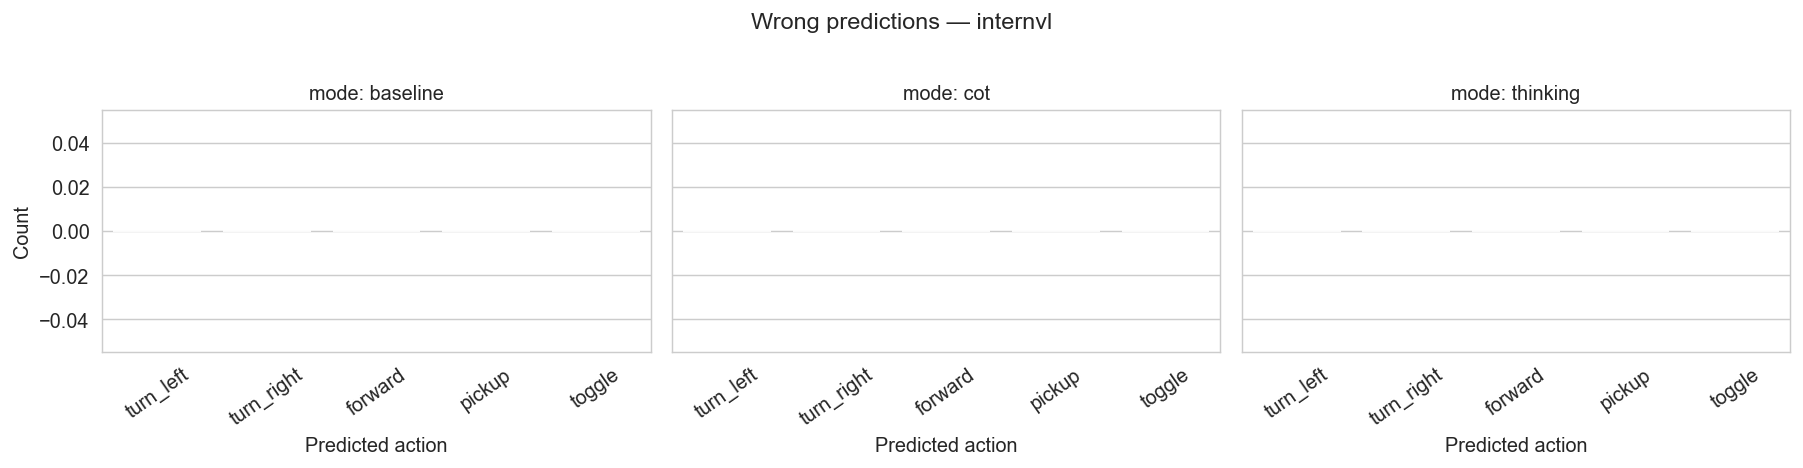

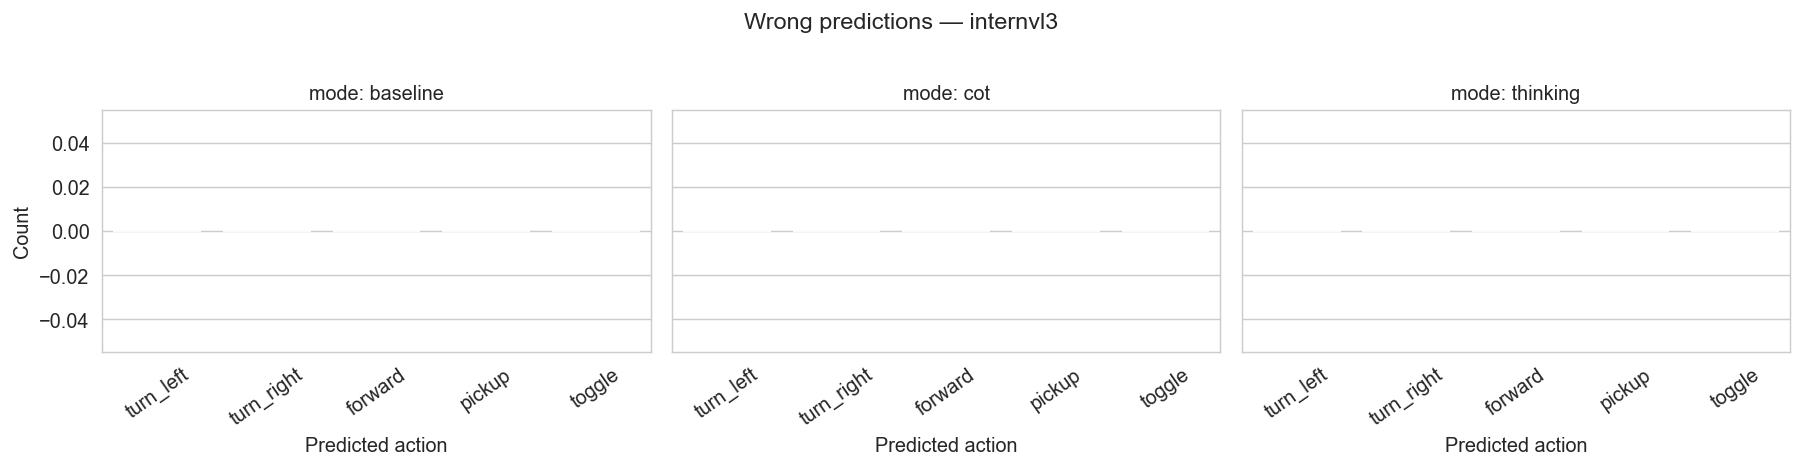

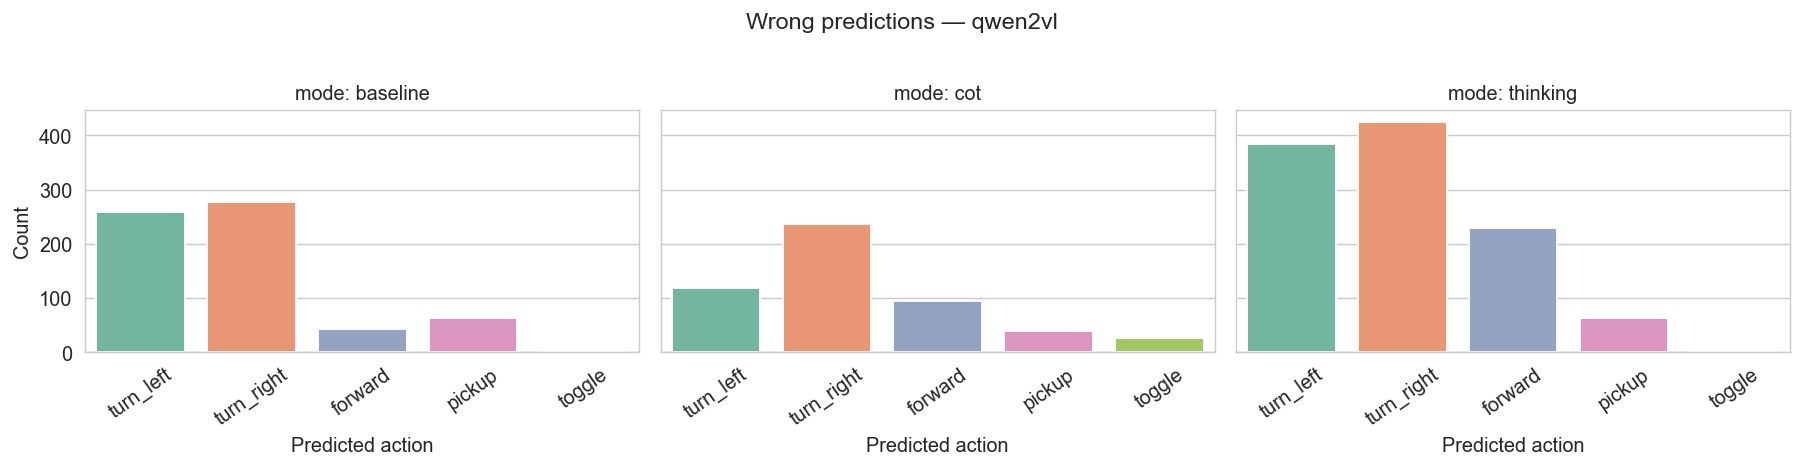

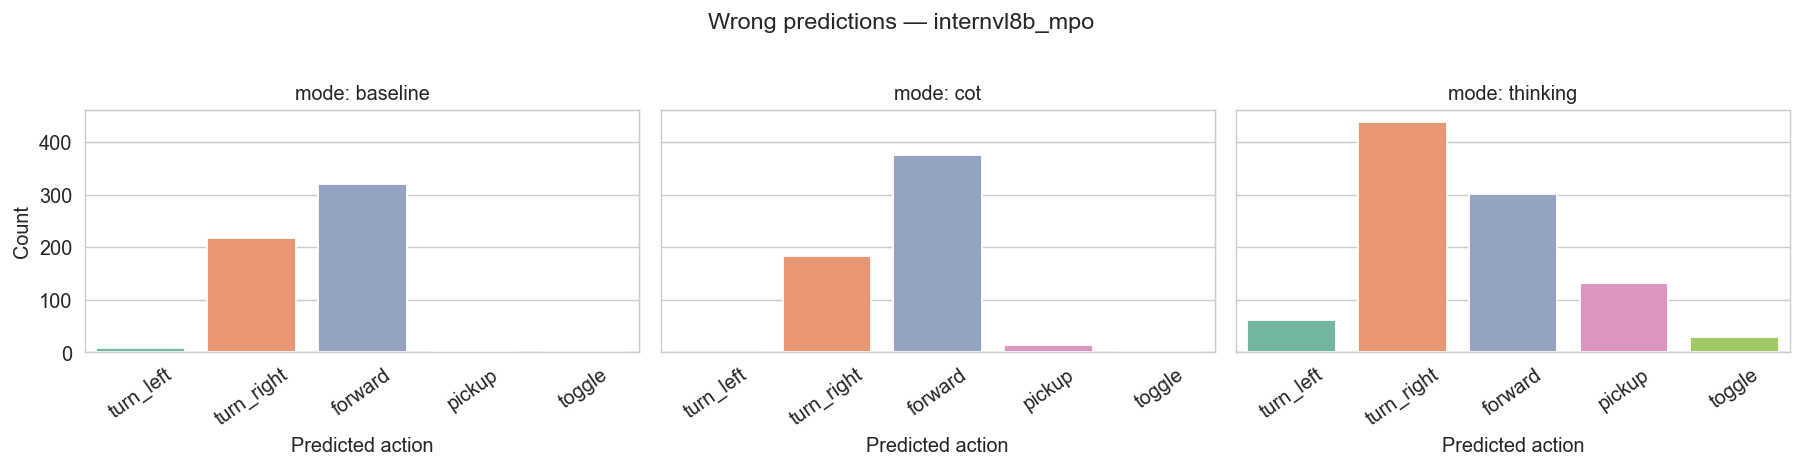

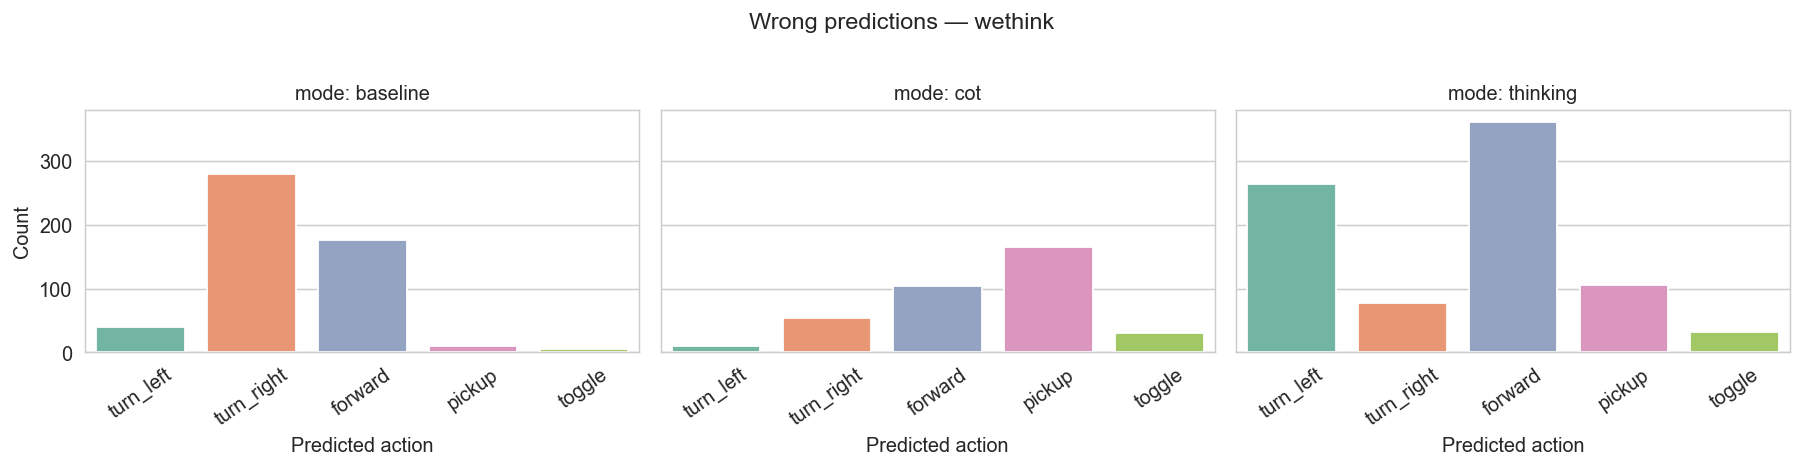

In [31]:
wrong = df[df["correct"] == False].copy()

# When wrong, what does each model predict? broken down by mode
for model in MODEL_ORDER:
    fig, axes = plt.subplots(1, len(MODE_ORDER), figsize=(14, 3.5), sharey=True)
    fig.suptitle(f"Wrong predictions — {model}", fontsize=13, y=1.02)

    for ax, mode in zip(axes, MODE_ORDER):
        sub = wrong[(wrong["model"] == model) & (wrong["mode"] == mode)]
        counts = sub["predicted_label"].value_counts().reindex(ACTION_LABELS, fill_value=0)
        sns.barplot(x=counts.index, y=counts.values, palette="Set2", ax=ax)
        ax.set_title(f"mode: {mode}", fontsize=11)
        ax.set_xlabel("Predicted action")
        ax.set_ylabel("Count" if mode == MODE_ORDER[0] else "")
        ax.tick_params(axis="x", rotation=35)

    plt.tight_layout()
    plt.show()

## 9. Response quality — correct / wrong / parse fail

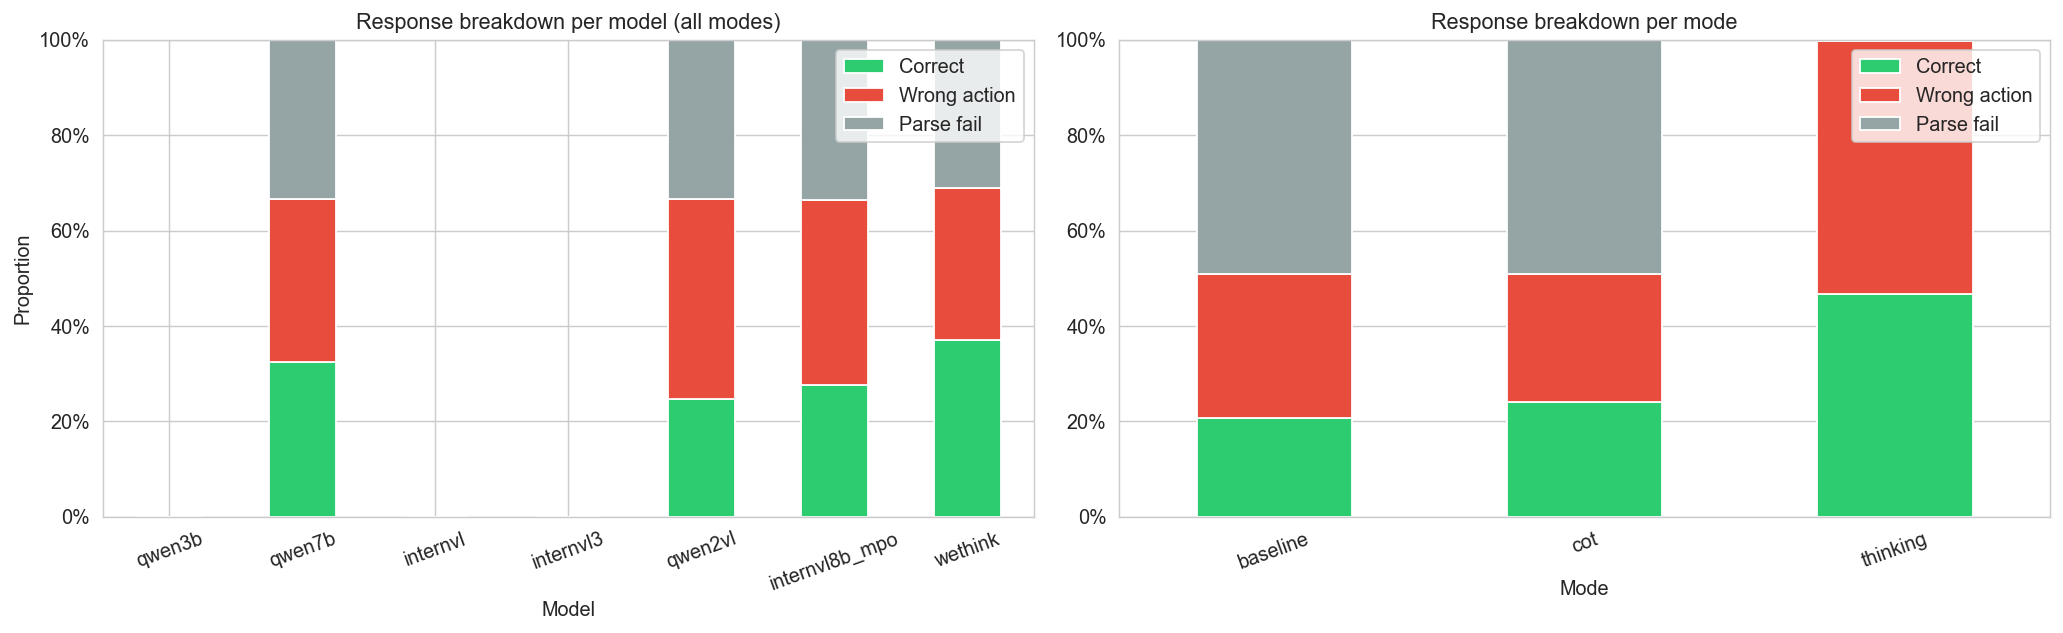

In [32]:
# Stacked bar per model (aggregated)
summary = df.groupby("model").agg(
    correct=("correct", "mean"),
    parse_fail=("parse_failed", "mean"),
).reindex(MODEL_ORDER)
summary["wrong"] = 1 - summary["correct"] - summary["parse_fail"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

summary[["correct", "wrong", "parse_fail"]].plot(
    kind="bar", stacked=True, ax=axes[0],
    color=["#2ecc71", "#e74c3c", "#95a5a6"],
    edgecolor="white"
)
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title("Response breakdown per model (all modes)", fontsize=12)
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Proportion")
axes[0].legend(["Correct", "Wrong action", "Parse fail"], loc="upper right")
axes[0].tick_params(axis="x", rotation=20)

# Same per mode
summary_mode = df.groupby("mode").agg(
    correct=("correct", "mean"),
    parse_fail=("parse_failed", "mean"),
).reindex(MODE_ORDER)
summary_mode["wrong"] = 1 - summary_mode["correct"] - summary_mode["parse_fail"]

summary_mode[["correct", "wrong", "parse_fail"]].plot(
    kind="bar", stacked=True, ax=axes[1],
    color=["#2ecc71", "#e74c3c", "#95a5a6"],
    edgecolor="white"
)
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Response breakdown per mode", fontsize=12)
axes[1].set_xlabel("Mode")
axes[1].set_ylabel("")
axes[1].legend(["Correct", "Wrong action", "Parse fail"], loc="upper right")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 10. Latency

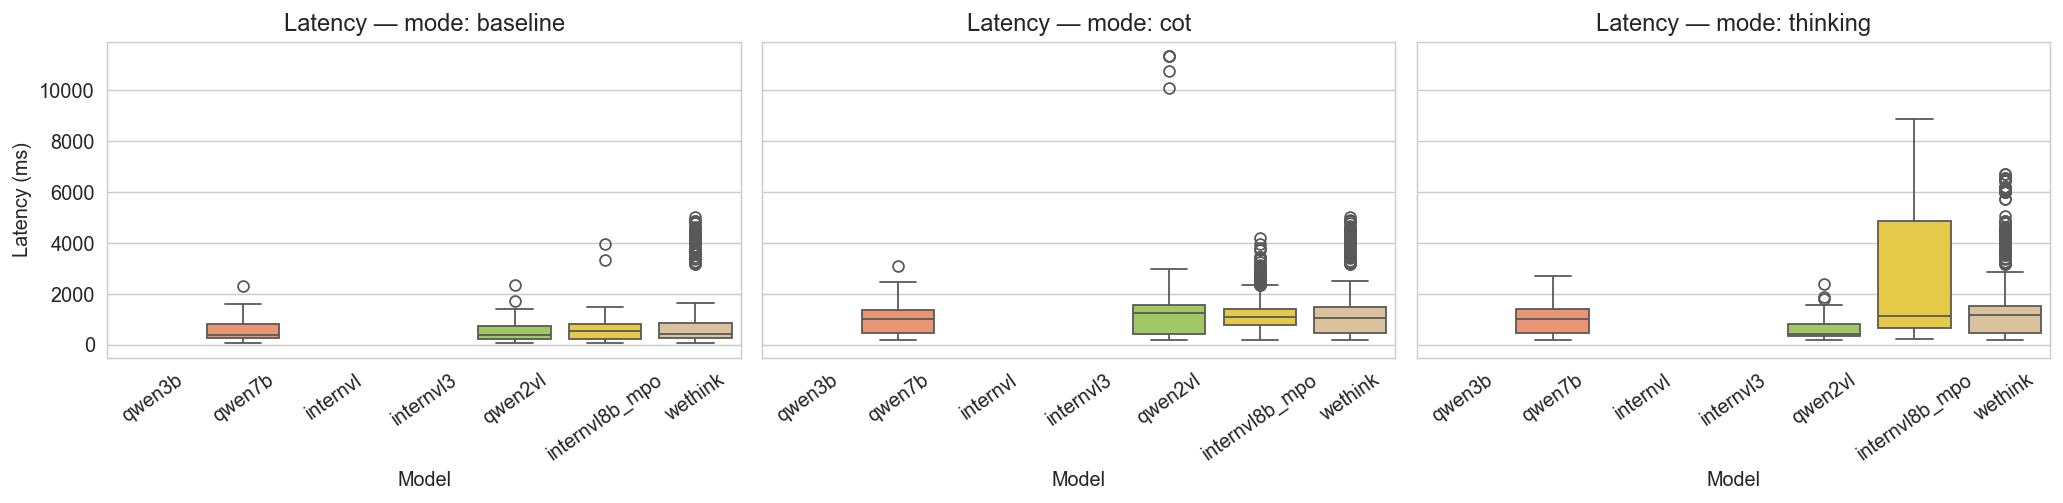

In [33]:
# Latency boxplot per model, split by mode
fig, axes = plt.subplots(1, len(MODE_ORDER), figsize=(16, 4), sharey=True)
for ax, mode in zip(axes, MODE_ORDER):
    sub = df[df["mode"] == mode]
    sns.boxplot(x="model", y="latency_ms", data=sub, order=MODEL_ORDER, palette="Set2", ax=ax)
    ax.set_title(f"Latency — mode: {mode}")
    ax.set_xlabel("Model")
    ax.set_ylabel("Latency (ms)" if mode == MODE_ORDER[0] else "")
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

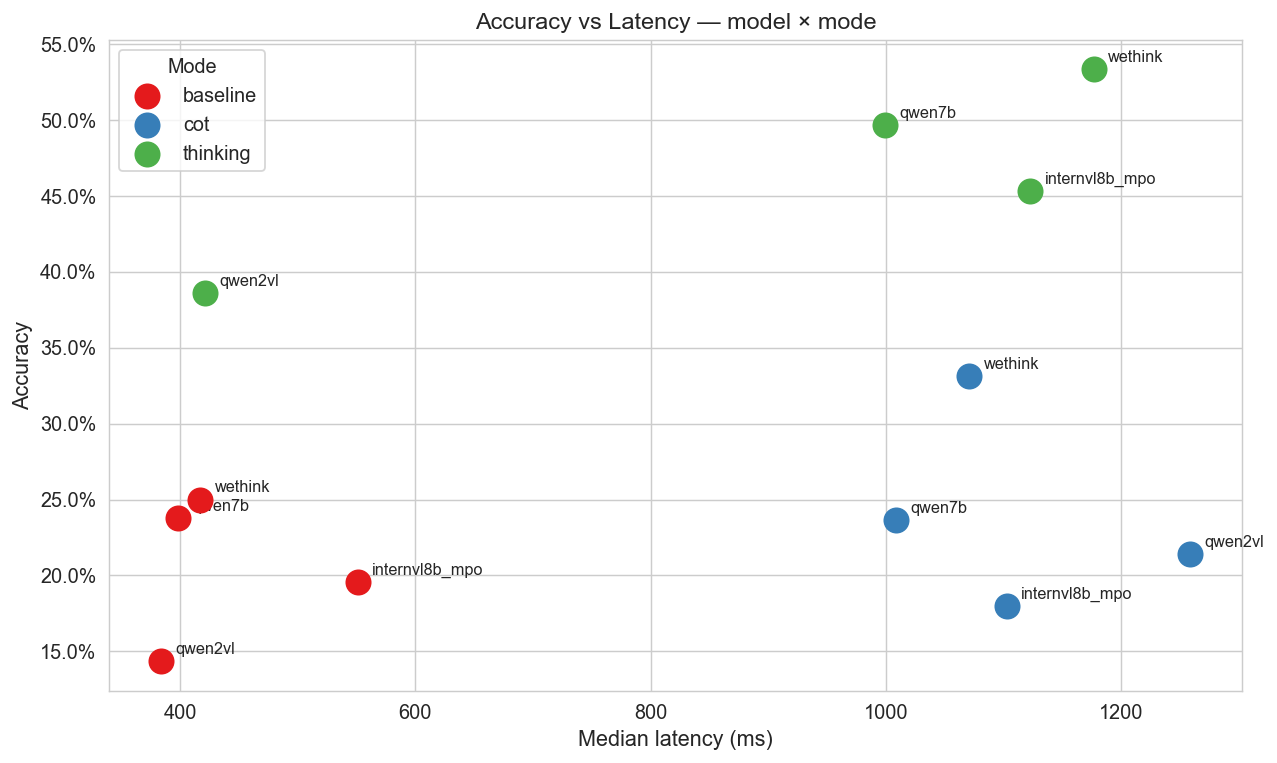

In [34]:
# Accuracy vs median latency — one point per (model, mode)
best = df.groupby(["model", "mode"]).agg(
    accuracy=("correct", "mean"),
    latency=("latency_ms", "median")
).reset_index()

palette = sns.color_palette("Set1", len(MODE_ORDER))
mode_color = {m: c for m, c in zip(MODE_ORDER, palette)}

fig, ax = plt.subplots(figsize=(10, 6))
for mode in MODE_ORDER:
    sub = best[best["mode"] == mode]
    ax.scatter(sub["latency"], sub["accuracy"], s=180, color=mode_color[mode], label=mode, zorder=5)
    for _, row in sub.iterrows():
        ax.annotate(
            row["model"],
            (row["latency"], row["accuracy"]),
            textcoords="offset points", xytext=(8, 4), fontsize=9
        )

ax.set_xlabel("Median latency (ms)", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Accuracy vs Latency — model × mode", fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(title="Mode")
plt.tight_layout()
plt.show()

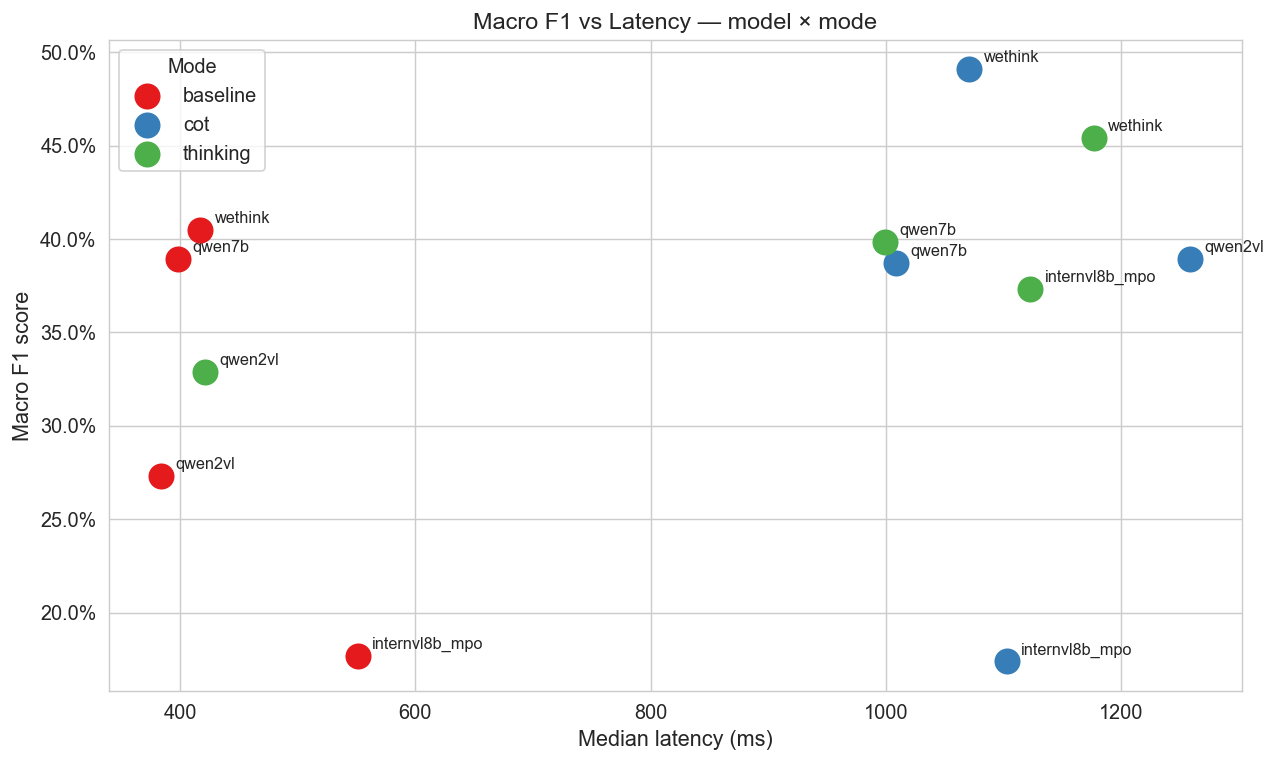

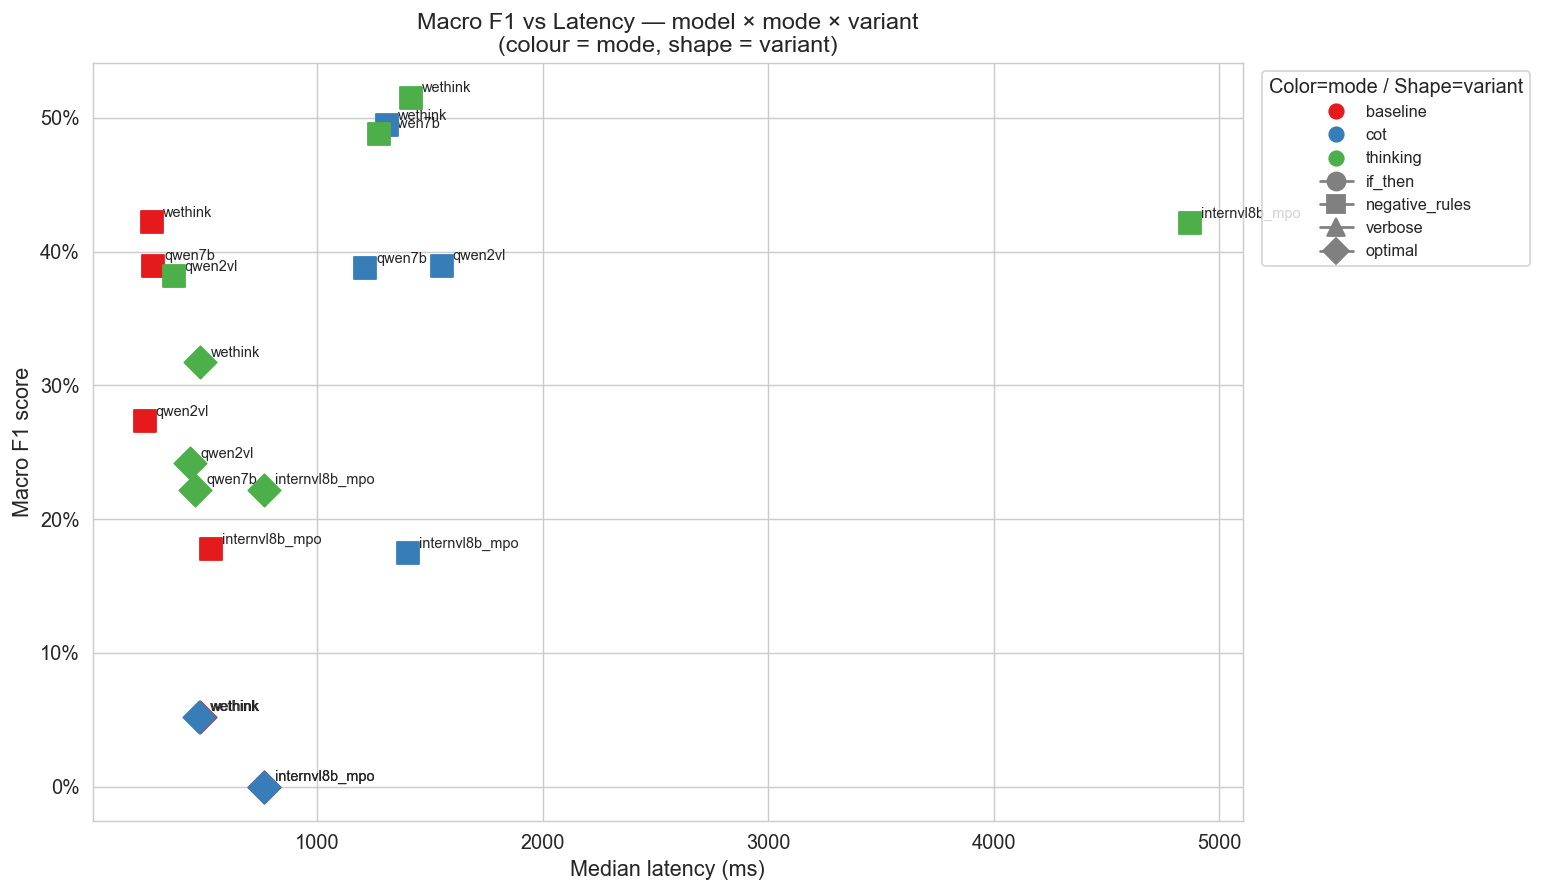

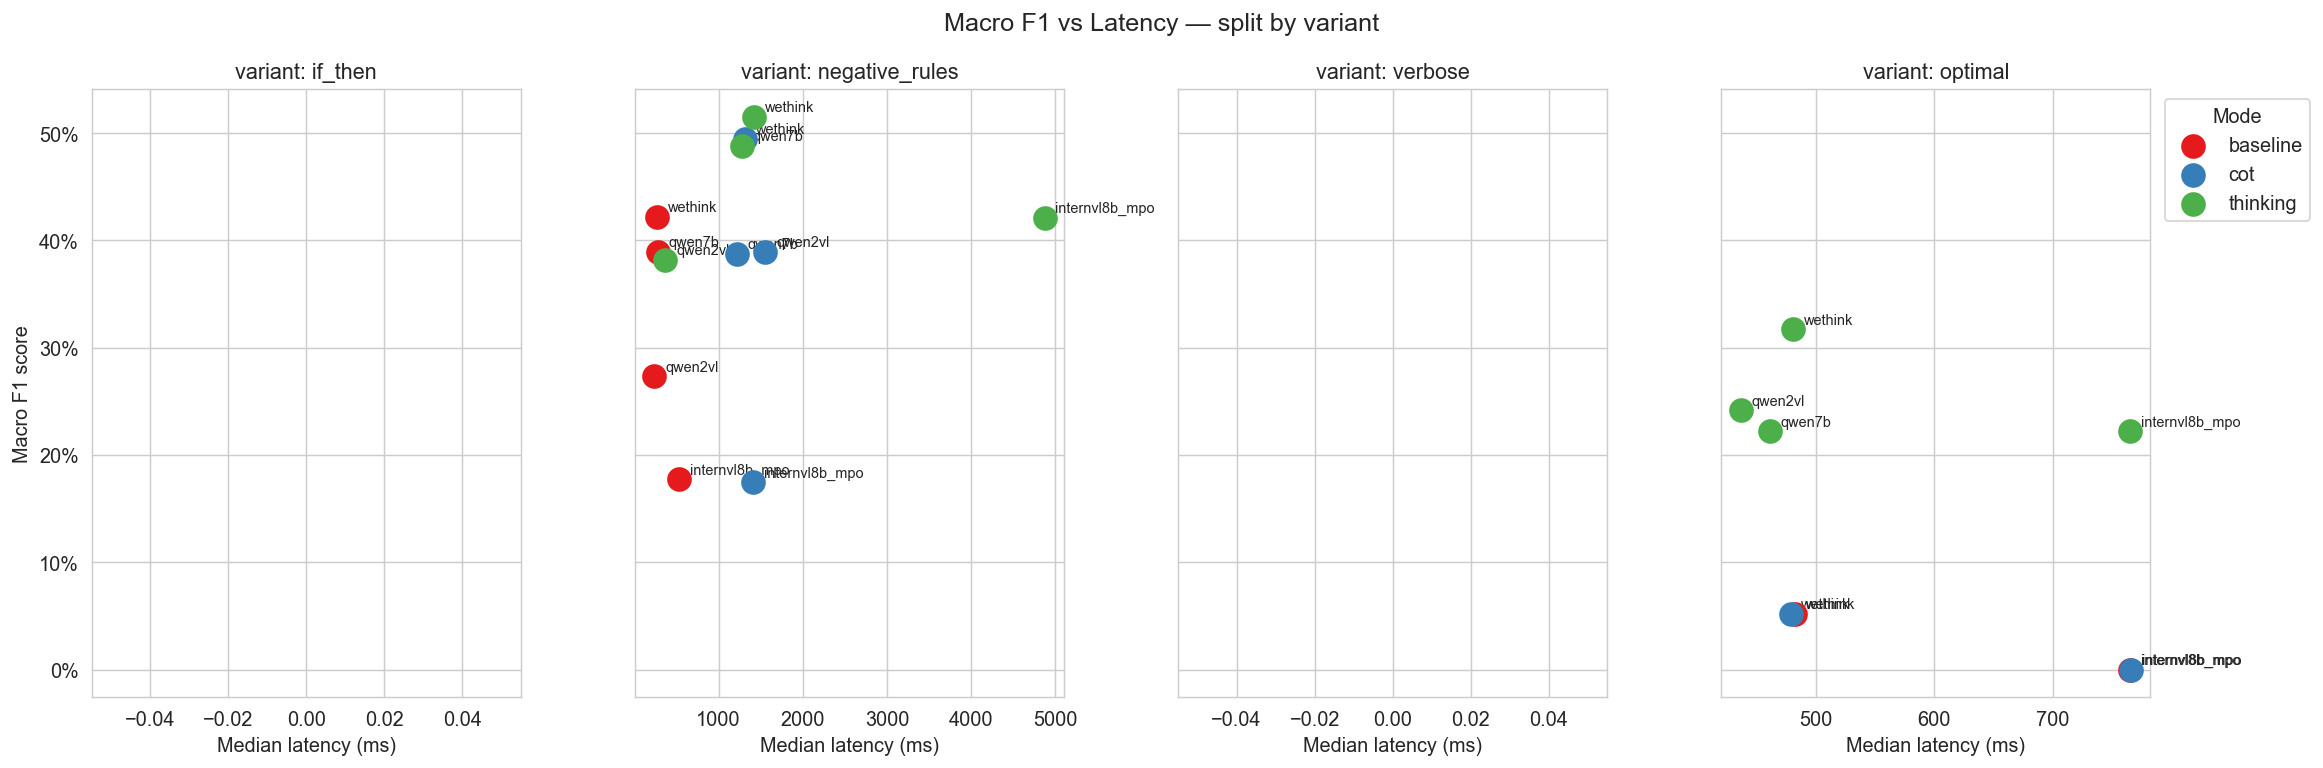

In [36]:
from sklearn.metrics import f1_score
import ast
import seaborn as sns

def _to_list(val):
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        return ast.literal_eval(val)
    return [int(val)]

def compute_f1(group):
    valid = group.dropna(subset=["predicted_action"])
    if len(valid) == 0:
        return np.nan
    y_true, y_pred = [], []
    for _, row in valid.iterrows():
        opt  = _to_list(row["optimal_actions"])
        pred = int(row["predicted_action"])
        y_pred.append(pred)
        y_true.append(pred if pred in opt else opt[0])
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

palette    = sns.color_palette("Set1", len(MODE_ORDER))
mode_color = {m: c for m, c in zip(MODE_ORDER, palette)}

VARIANT_MARKERS = {"if_then": "o", "negative_rules": "s", "verbose": "^", "optimal": "D"}

# ── F1 vs Latency — model × mode ─────────────────────────────────────────────
f1_stats  = df.groupby(["model", "mode"]).apply(compute_f1).reset_index(name="f1")
lat_stats = df.groupby(["model", "mode"])["latency_ms"].median().reset_index(name="latency")
f1_df     = f1_stats.merge(lat_stats, on=["model", "mode"])

fig, ax = plt.subplots(figsize=(10, 6))
for mode in MODE_ORDER:
    sub = f1_df[f1_df["mode"] == mode]
    ax.scatter(sub["latency"], sub["f1"], s=180, color=mode_color[mode], label=mode, zorder=5)
    for _, row in sub.iterrows():
        ax.annotate(row["model"], (row["latency"], row["f1"]),
                    textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.set_xlabel("Median latency (ms)", fontsize=12)
ax.set_ylabel("Macro F1 score", fontsize=12)
ax.set_title("Macro F1 vs Latency — model × mode", fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(title="Mode")
plt.tight_layout()
plt.show()

# ── F1 vs Latency — model × mode × variant ───────────────────────────────────
f1_v  = df.groupby(["model", "mode", "variant"]).apply(compute_f1).reset_index(name="f1")
lat_v = df.groupby(["model", "mode", "variant"])["latency_ms"].median().reset_index(name="latency")
f1_var_df = f1_v.merge(lat_v, on=["model", "mode", "variant"])

fig, ax = plt.subplots(figsize=(12, 7))
for mode in MODE_ORDER:
    for variant in VARIANT_ORDER:
        sub = f1_var_df[(f1_var_df["mode"] == mode) & (f1_var_df["variant"] == variant)]
        ax.scatter(
            sub["latency"], sub["f1"],
            s=160, color=mode_color[mode],
            marker=VARIANT_MARKERS[variant],
            zorder=5,
            label=f"{mode} / {variant}" if variant == VARIANT_ORDER[0] else "_nolegend_"
        )
        for _, row in sub.iterrows():
            ax.annotate(row["model"], (row["latency"], row["f1"]),
                        textcoords="offset points", xytext=(6, 3), fontsize=8)

# Custom legend: colours = modes, markers = variants
from matplotlib.lines import Line2D
legend_elements = (
    [Line2D([0], [0], marker="o", color="w", markerfacecolor=mode_color[m],
             markersize=10, label=m) for m in MODE_ORDER]
    + [Line2D([0], [0], marker=VARIANT_MARKERS[v], color="gray",
               markersize=10, label=v) for v in VARIANT_ORDER]
)
ax.legend(handles=legend_elements, title="Color=mode / Shape=variant",
          bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)

ax.set_xlabel("Median latency (ms)", fontsize=12)
ax.set_ylabel("Macro F1 score", fontsize=12)
ax.set_title("Macro F1 vs Latency — model × mode × variant\n(colour = mode, shape = variant)", fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

# ── F1 vs Latency — one subplot per variant ───────────────────────────────────
fig, axes = plt.subplots(1, len(VARIANT_ORDER), figsize=(18, 6), sharey=True)
fig.suptitle("Macro F1 vs Latency — split by variant", fontsize=14)

for ax, variant in zip(axes, VARIANT_ORDER):
    sub_v = f1_var_df[f1_var_df["variant"] == variant]
    for mode in MODE_ORDER:
        sub = sub_v[sub_v["mode"] == mode]
        ax.scatter(sub["latency"], sub["f1"], s=160, color=mode_color[mode], label=mode, zorder=5)
        for _, row in sub.iterrows():
            ax.annotate(row["model"], (row["latency"], row["f1"]),
                        textcoords="offset points", xytext=(6, 3), fontsize=8)
    ax.set_title(f"variant: {variant}", fontsize=12)
    ax.set_xlabel("Median latency (ms)")
    if variant == VARIANT_ORDER[0]:
        ax.set_ylabel("Macro F1 score")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    if variant == VARIANT_ORDER[-1]:
        ax.legend(title="Mode", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 11. Summary table — best configuration per model

In [ ]:
# Best accuracy config per model (mode × variant × history_type)
summary_full = df.groupby(["model", "mode", "variant", "history_type"]).agg(
    accuracy=("correct", "mean"),
    latency=("latency_ms", "median"),
    parse_fail=("parse_failed", "mean"),
    n=("correct", "count")
).reset_index()

best_per_model = summary_full.loc[summary_full.groupby("model")["accuracy"].idxmax()]
best_per_model = best_per_model.sort_values("accuracy", ascending=False).reset_index(drop=True)

best_per_model["accuracy"] = best_per_model["accuracy"].map("{:.1%}".format)
best_per_model["parse_fail"] = best_per_model["parse_fail"].map("{:.1%}".format)
best_per_model["latency"] = best_per_model["latency"].map("{:.0f} ms".format)

best_per_model

,model,mode,variant,history_type,accuracy,latency,parse_fail,n
0,wethink,cot,negative_rules,optimal,88.2%,1374 ms,0.0%,558
1,internvl8b_mpo,thinking,negative_rules,optimal,67.9%,5008 ms,0.0%,558
2,qwen7b,thinking,negative_rules,optimal,66.7%,1290 ms,0.0%,558
3,qwen2vl,thinking,optimal,suboptimal,45.3%,438 ms,0.0%,342


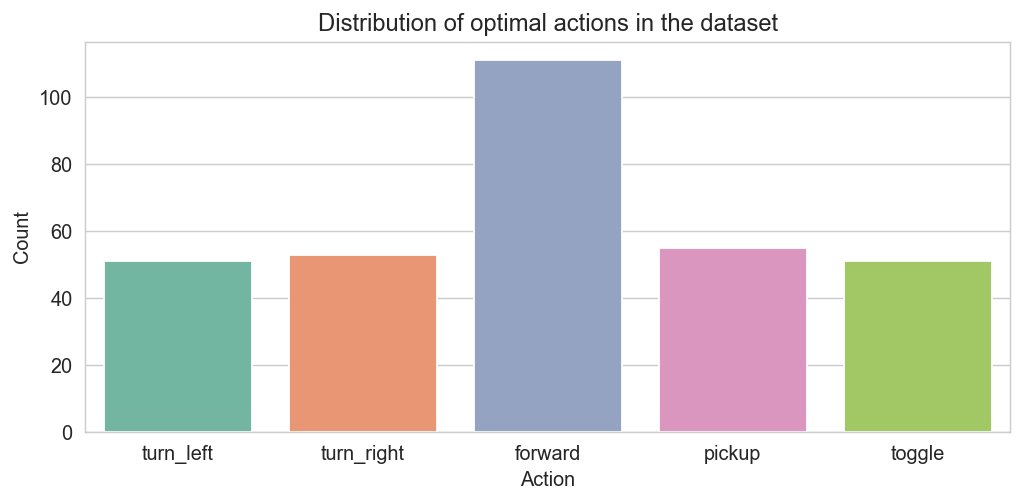

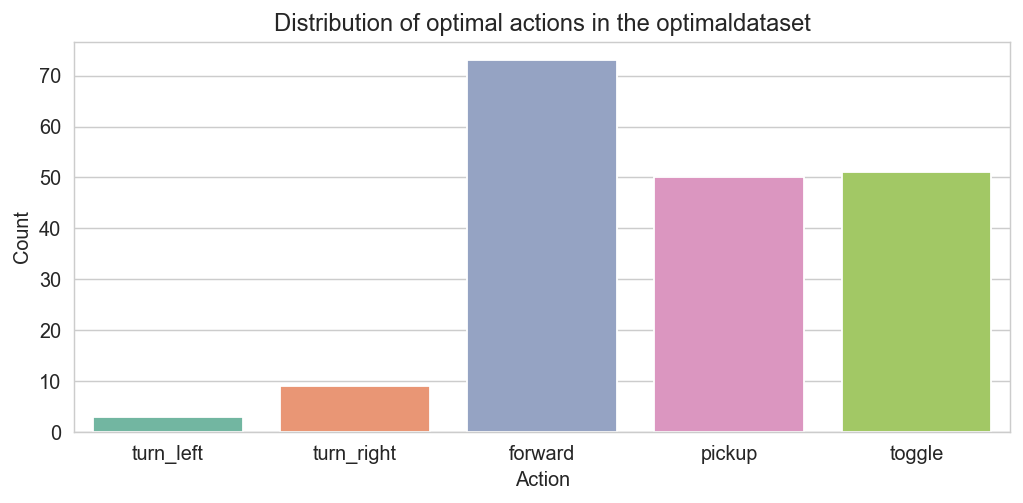

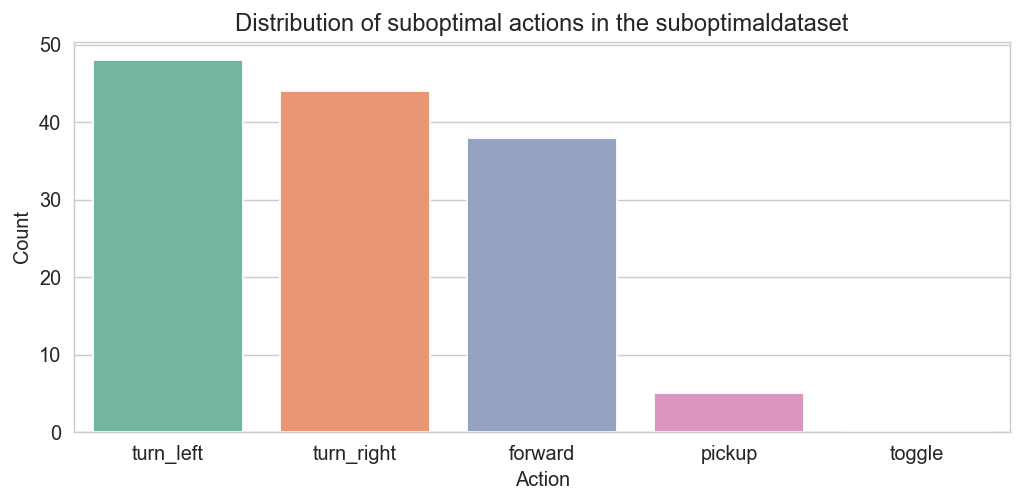

In [ ]:
# Distribution of each action_names in the dataset
with open("history_dataset/dataset.json") as f:
    hist_data = json.load(f)

action_counts = {action: 0 for action in ACTION_LABELS}
action_opt = {action: 0 for action in ACTION_LABELS}
action_subopt = {action: 0 for action in ACTION_LABELS}
for item in hist_data:
    for action in item["action_names"]:
        if action in action_counts:
            action_counts[action] += 1
        if action in action_opt and item["history_type"] == "optimal":
            action_opt[action] += 1
        if action in action_subopt and item["history_type"] == "suboptimal":
            action_subopt[action] += 1

action_df = pd.DataFrame({
    "action": ACTION_LABELS,
    "count": [action_counts[a] for a in ACTION_LABELS],
    "optimal": [action_opt[a] for a in ACTION_LABELS],
    "suboptimal": [action_subopt[a] for a in ACTION_LABELS],
})
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x="action", y="count", data=action_df, palette="Set2", ax=ax)
ax.set_title("Distribution of optimal actions in the dataset")
ax.set_xlabel("Action")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x="action", y="optimal", data=action_df, palette="Set2", ax=ax)
ax.set_title("Distribution of optimal actions in the optimaldataset")
ax.set_xlabel("Action")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x="action", y="suboptimal", data=action_df, palette="Set2", ax=ax)
ax.set_title("Distribution of suboptimal actions in the suboptimaldataset")
ax.set_xlabel("Action")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()
